In [661]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib.ticker as ticker 
from matplotlib.axis import Axis 
import datetime as dt
from datetime import datetime, date
#plt.style.use(['science', 'notebook'])
# %matplotlib inline

import time
begin = time.time()

### Le fichier temp03062024.csv est mis à jour par weather_bis.py sur pi4 dans terminal
### A partir de 02/01/2026 10h, weather_ter.py marche en double pour créer le csv temp02012026.csv


In [662]:

#csv_file1 = r"Y:\Documents\temp16122022.csv.old"  # saved 16/12/2022

# 2024-2026
csv_file1 = r"Y:\Documents\temp03062024.csv"

# 2026
#csv_file1 = r"Y:\Documents\temp02012026.csv"

#csv_file2 = r"Z:\Documents\temp16122022.csv"


In [663]:

def read_text(filename):
    f = open(filename, "r")
    text = f.readlines()
    f.close()
    print(text)


def get_data(filename):    
    data = pd.read_csv(filename)
    #data['time'] = pd.to_datetime(data['time'])  #.dt.tz_convert(None)
    #data.info()
    #print(data.tail(5))
    return data

try:
    data = get_data(csv_file1)
except:
    data = get_data(csv_file2)
#data['heure'] = pd.to_datetime(data['time']).dt.strftime('%H:%M') #time
#data['jour'] = pd.to_datetime(data['time']).dt.strftime('%d/%m') #date
len(data), data

(20258,
         temp
 0      13.19
 1      12.20
 2      12.29
 3      12.42
 4      14.54
 ...      ...
 20253  26.00
 20254  28.45
 20255  31.26
 20256  33.75
 20257  35.31
 
 [20258 rows x 1 columns])

In [664]:
def from_csv(csv_file):    
    df = pd.read_csv(csv_file)
    return df

def to_csv(csv_file, df):
    df.to_csv(csv_file, index=False)


<Axes: >

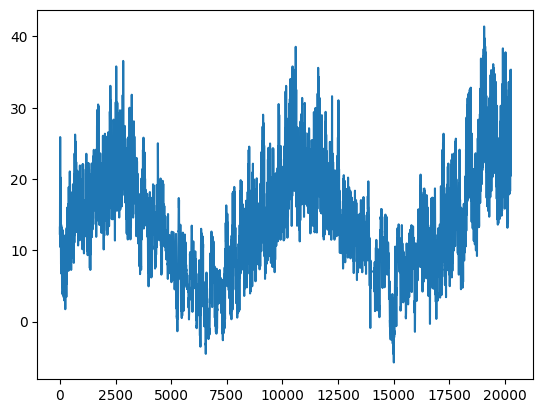

In [665]:
data['temp'].plot()

In [666]:
csv_file1

'Y:\\Documents\\temp03062024.csv'

In [667]:
# convert string to datetime

date_time_str = '16/04/24 07:00:00'   # avant 2026
# décalage car il manque des data sur 5 jours et 6 heures fin 2025
date_time_str = '21/04/24 13:00:00'   # date de début des data 2024-2026
if csv_file1 == r"Y:\Documents\temp02012026.csv":
    date_time_str = '03/01/26 08:00:00'    # début 2026
ref = datetime.strptime(date_time_str, '%d/%m/%y %H:%M:%S')

then = ref + dt.timedelta(hours=len(data))
ref,then

(datetime.datetime(2024, 4, 21, 13, 0), datetime.datetime(2026, 8, 13, 15, 0))

In [668]:
len(data), date_time_str

(20258, '21/04/24 13:00:00')

In [669]:
def mk_date(date_time_str,data):
    # 
    ref = datetime.strptime(date_time_str, '%d/%m/%y %H:%M:%S')
    then = ref + dt.timedelta(hours=len(data))
    return mdates.drange(ref,then,dt.timedelta(hours=1))


In [670]:
hours = mk_date(date_time_str,data)
#len(hours)
dates = [datetime.strftime(h, '%d/%m/%y %H:%M:%S') for h in mdates.num2date(hours)]
#dates
if len(data)<len(hours):
    data['hours']=hours[:-1]
    data['dates']=dates[:-1]
else:
    data['hours']=hours
    data['dates']=dates
data

,temp,hours,dates
0,13.19,19834.541667,21/04/24 13:00:00
1,12.20,19834.583333,21/04/24 14:00:00
2,12.29,19834.625000,21/04/24 15:00:00
3,12.42,19834.666667,21/04/24 16:00:00
4,14.54,19834.708333,21/04/24 17:00:00
...,...,...,...
20253,26.00,20678.416667,13/08/26 10:00:00
20254,28.45,20678.458333,13/08/26 11:00:00
20255,31.26,20678.500000,13/08/26 12:00:00
20256,33.75,20678.541667,13/08/26 13:00:00


In [671]:
data[['dates','temp']]

,dates,temp
0,21/04/24 13:00:00,13.19
1,21/04/24 14:00:00,12.20
2,21/04/24 15:00:00,12.29
3,21/04/24 16:00:00,12.42
4,21/04/24 17:00:00,14.54
...,...,...
20253,13/08/26 10:00:00,26.00
20254,13/08/26 11:00:00,28.45
20255,13/08/26 12:00:00,31.26
20256,13/08/26 13:00:00,33.75


In [672]:
import warnings
warnings.filterwarnings("ignore")


In [673]:
# data des 24 premieres heures
d_24 = data[:24]['temp']
#d_24


In [674]:
# moyenne des premieres 24 heures
m_day = d_24.mean()
m_day

np.float64(19.400000000000016)

In [675]:
# moyenne sur 24 heures depuis le 16/12/2022 9h
mean_all = []
window = 24
h_w = window//2
for l in range(len(data)-window):
    d_24 = data[l:l+window]['temp'].mean()
    mean_all.append(d_24)
x = data[:-window]['hours'].values    
len(mean_all), len(x)

(20234, 20234)

In [676]:
def format_date(space=3):
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))  #('%d/%m\n%H:%M'))
    #plt.gca().xaxis.set_major_locator(mdates.HourLocator(space))
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=space*5))
    plt.gcf().autofmt_xdate()
    plt.grid()

Text(0.5, 1.0, 'Moyenne sur 24 heures sur 7 jours')

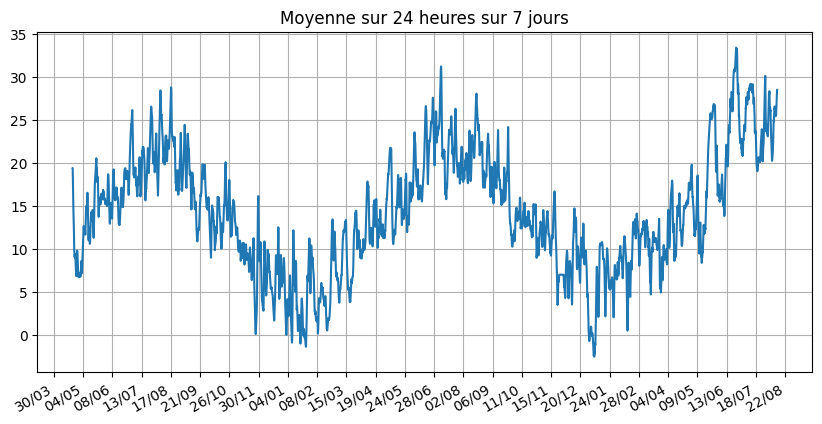

In [677]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
plt.plot(x,mean_all, markersize=1)
jours = 7
format_date(jours*24) # jours x 24 h
plt.title(f'Moyenne sur 24 heures sur {jours} jours') #depuis le 16/12/2022')
#plt.grid()

In [678]:
today = datetime.now()
diff = today - ref
diff

datetime.timedelta(days=844, seconds=4293, microseconds=878329)

In [679]:
days = diff.days + diff.seconds/(24*3600)
days = int(days)


In [680]:
# moyenne depuis le 16/12/22
slice = int(days*24)
h = data.tail(slice).hours
t = data.tail(slice).temp
#h, t
ref,today,days


(datetime.datetime(2024, 4, 21, 13, 0),
 datetime.datetime(2026, 8, 13, 14, 11, 33, 878329),
 844)

In [681]:
temp = data['temp']
moyenne = data['temp'].mean()
moyenne

np.float64(14.234482179879578)

np.float64(14.234482179879578)

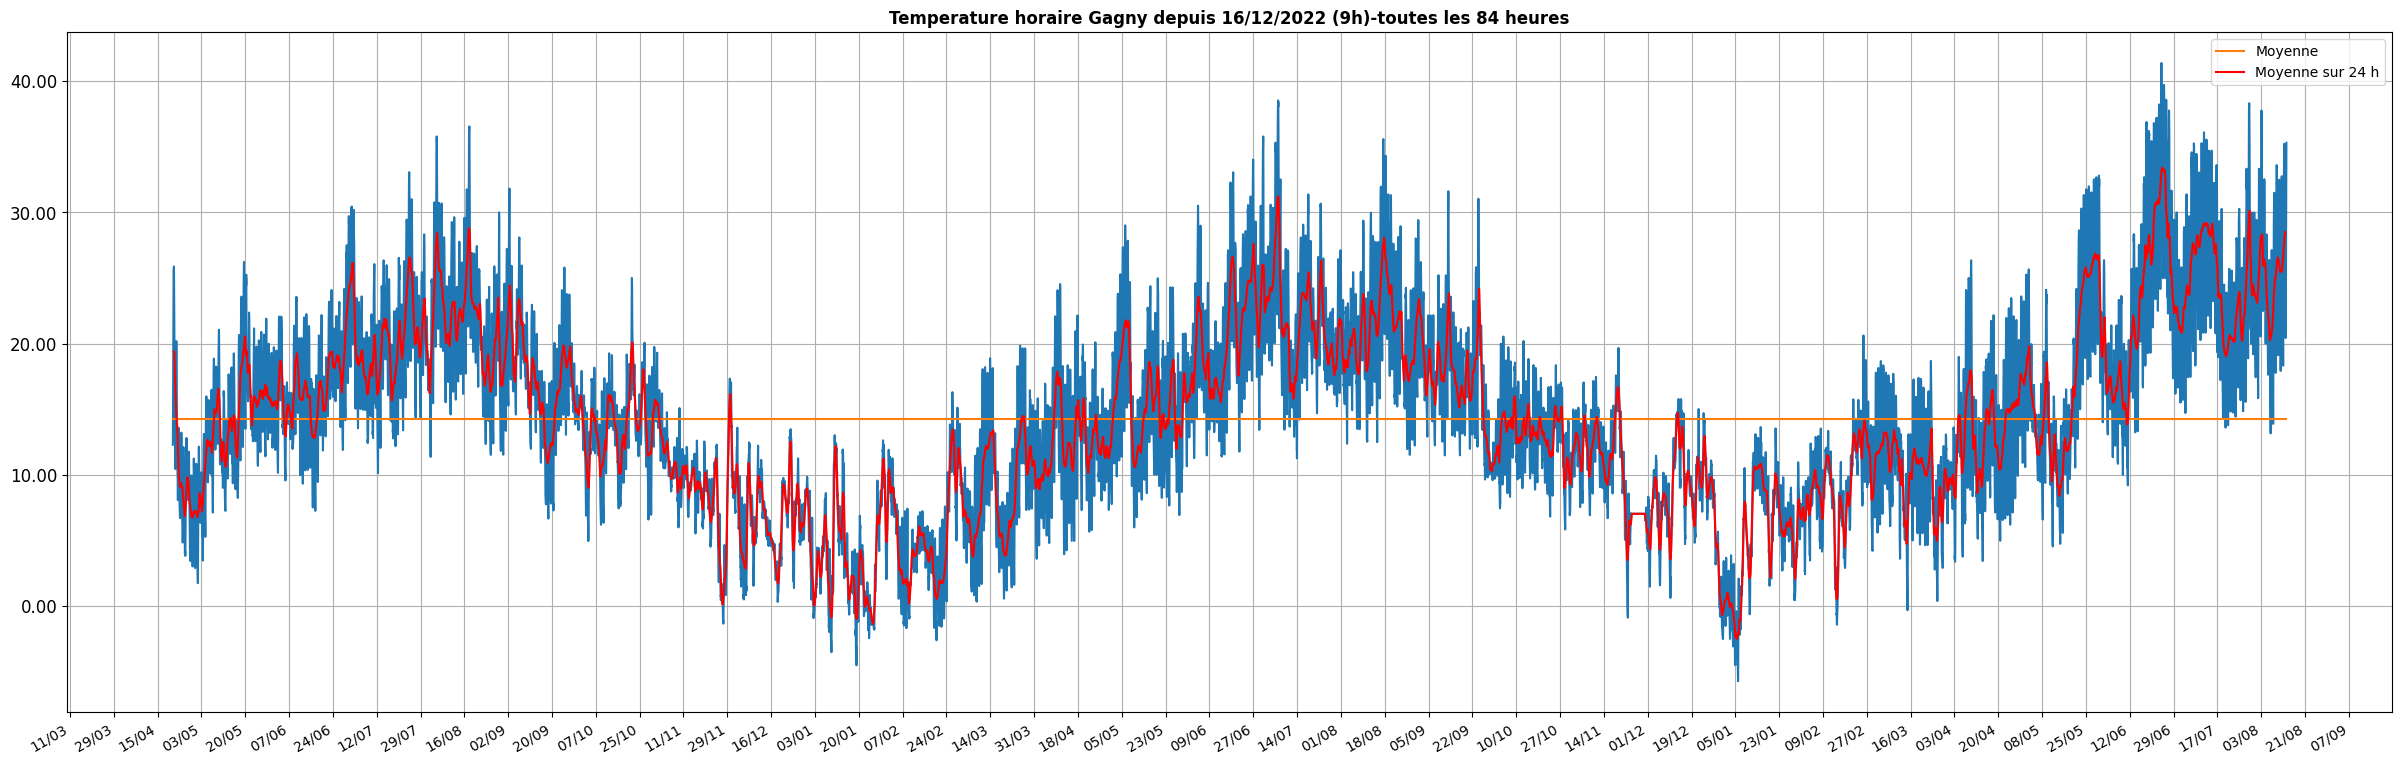

In [682]:
interval = 84
fig, ax = plt.subplots()
fig.set_size_inches(30, 10)
#plot = data['temp'].plot(figsize=(12,6))
plt.plot(h,t)
h1 = h.head(1)
h2 = h.tail(1)
plt.plot((h1,h2),(moyenne, moyenne),label='Moyenne')
plt.plot(hours[h_w:len(data)-h_w],mean_all,'r-',label=f'Moyenne sur {window} h')
#plt.plot(hours,temp)
plt.title(f"Temperature horaire Gagny depuis 16/12/2022 (9h)-toutes les {interval} heures",fontweight ='bold')


plt.legend()
#ax.set_xticks(hours)
ax.set_xticklabels(hours,fontsize=10)
#ax.set_yticks()
ax.set_yticklabels(temp,fontsize=12)

# Y_axis
formatter = ticker.FormatStrFormatter('%1.2f')
Axis.set_major_formatter(ax.yaxis, formatter)
format_date(12*7)
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m:%H:%M'))
# plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=interval))
# plt.gcf().autofmt_xdate()
# plt.grid()
moyenne


In [683]:
data['variation']=data['temp'].diff()
data

,temp,hours,dates,variation
0,13.19,19834.541667,21/04/24 13:00:00,NaN
1,12.20,19834.583333,21/04/24 14:00:00,-0.99
2,12.29,19834.625000,21/04/24 15:00:00,0.09
3,12.42,19834.666667,21/04/24 16:00:00,0.13
4,14.54,19834.708333,21/04/24 17:00:00,2.12
...,...,...,...,...
20253,26.00,20678.416667,13/08/26 10:00:00,1.43
20254,28.45,20678.458333,13/08/26 11:00:00,2.45
20255,31.26,20678.500000,13/08/26 12:00:00,2.81
20256,33.75,20678.541667,13/08/26 13:00:00,2.49


In [684]:
today

datetime.datetime(2026, 8, 13, 14, 11, 33, 878329)

<Axes: >

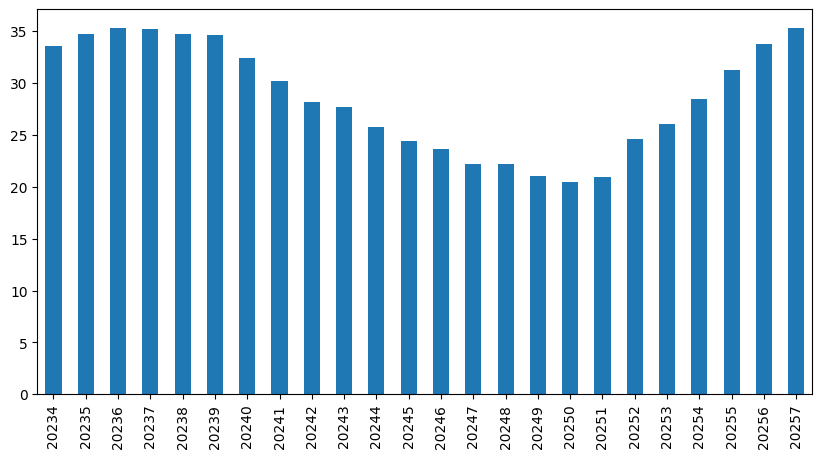

In [685]:
data.tail(24)['temp'].plot.bar(figsize=(10,5))

In [686]:
data

,temp,hours,dates,variation
0,13.19,19834.541667,21/04/24 13:00:00,NaN
1,12.20,19834.583333,21/04/24 14:00:00,-0.99
2,12.29,19834.625000,21/04/24 15:00:00,0.09
3,12.42,19834.666667,21/04/24 16:00:00,0.13
4,14.54,19834.708333,21/04/24 17:00:00,2.12
...,...,...,...,...
20253,26.00,20678.416667,13/08/26 10:00:00,1.43
20254,28.45,20678.458333,13/08/26 11:00:00,2.45
20255,31.26,20678.500000,13/08/26 12:00:00,2.81
20256,33.75,20678.541667,13/08/26 13:00:00,2.49


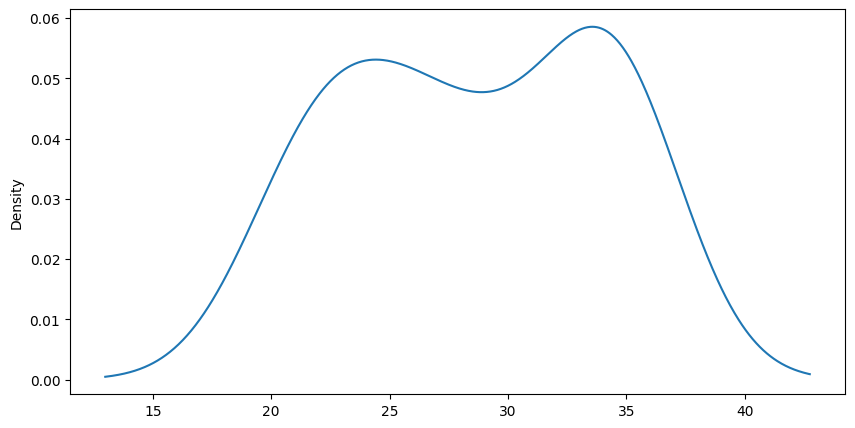

In [687]:
span = 24
try:
    data.tail(span)['temp'].plot.kde(figsize=(10,5))
    #data['temp'].plot.kde(figsize=(10,5))
except:
    pass

<Axes: ylabel='Frequency'>

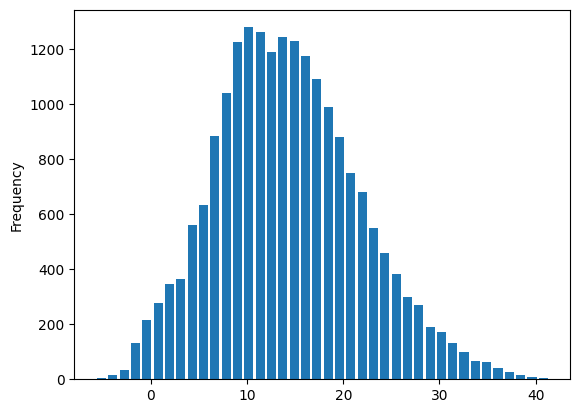

In [688]:
data['temp'].plot.hist(bins=40,rwidth=0.8) #,histtype='step')


In [689]:
#data['temp'].plot.kde(xlim=(-10,40)) #,logy=True)

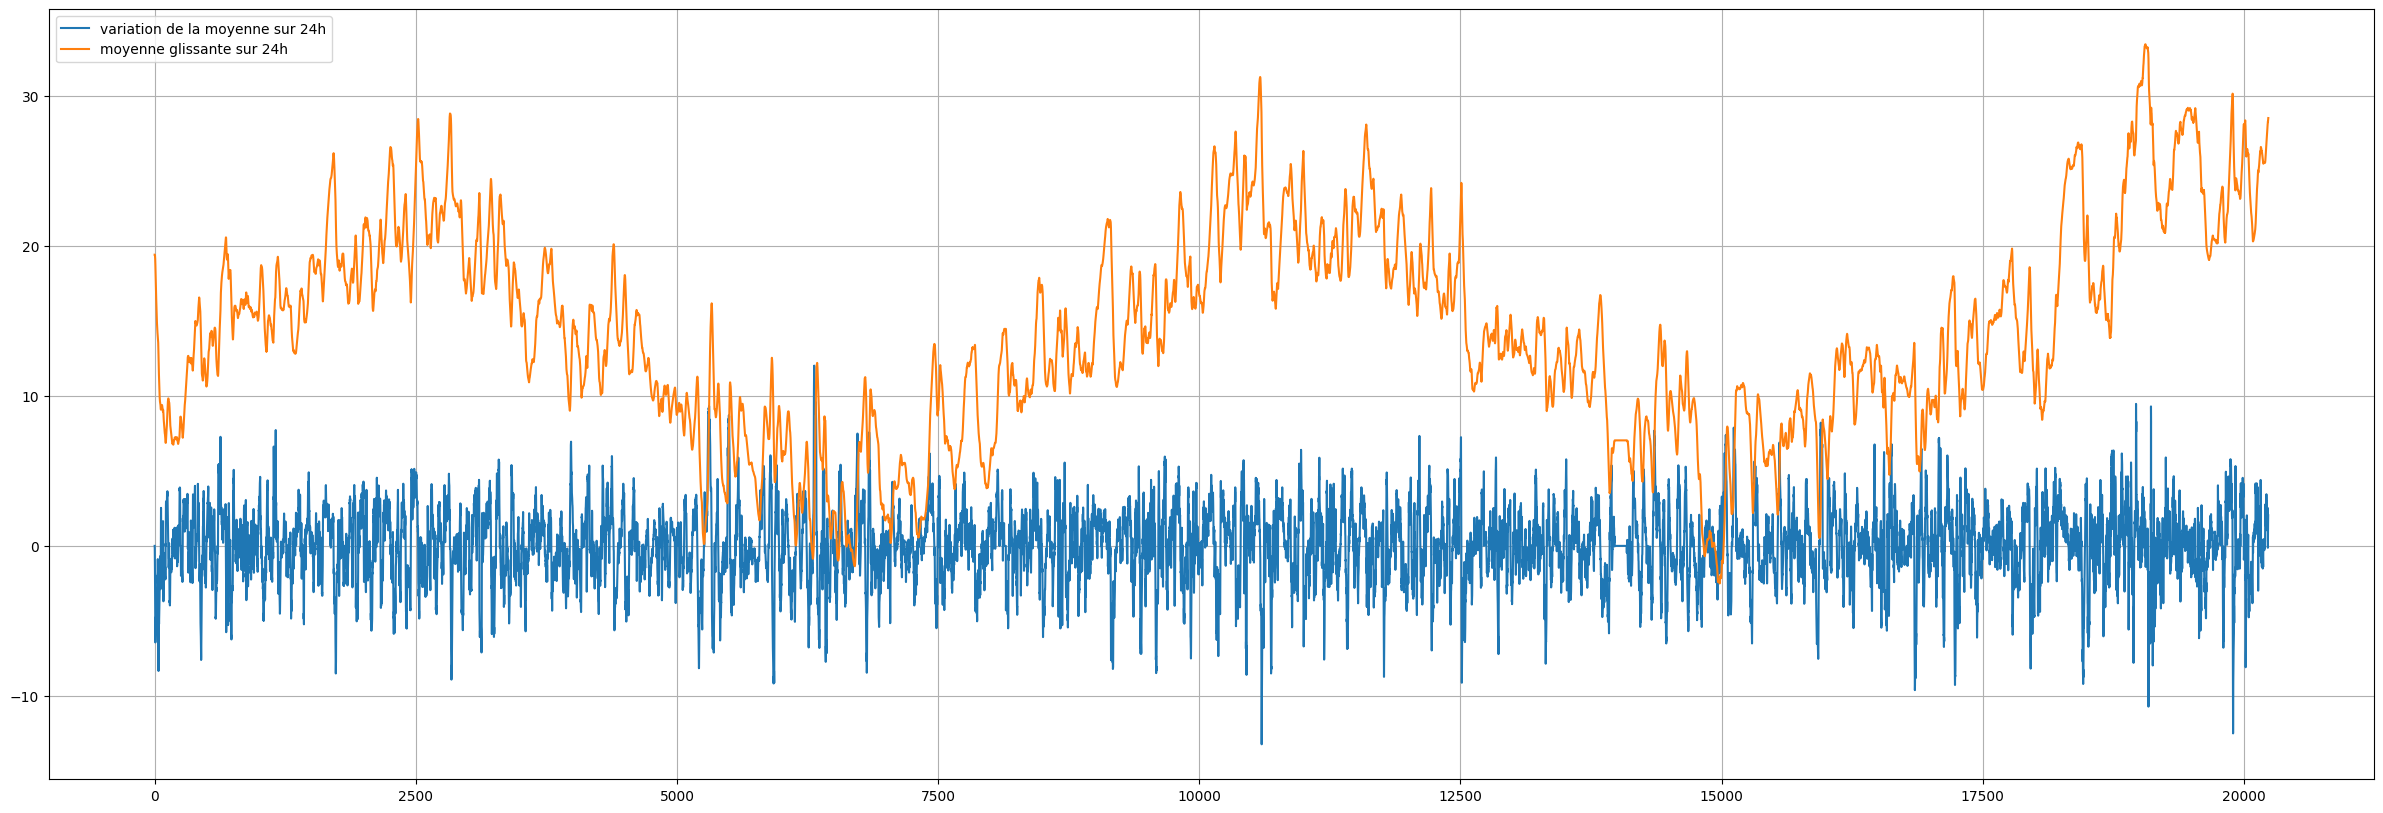

In [690]:
# variation horaire
fig, ax = plt.subplots()
fig.set_size_inches(30, 10)
delta = np.diff(mean_all)
facteur = 20   # amplifie la variation delta
plt.plot(facteur*delta,label='variation de la moyenne sur 24h')
plt.plot(mean_all,label='moyenne glissante sur 24h')
plt.legend()
plt.grid()

## Définir une fenêtre de visualisation : days

In [691]:
# fenetre de visualisation
days = 15
#days = int(len(data)/24)  # sur toute la liste de data


# xAxis interval
if days>30:
    interval = 72
elif days>15:
    interval = 24
elif days>7:
    interval = 12
else:
    interval = 6


In [692]:
window, days, interval

(24, 15, 12)

In [693]:
# moyenne avec une fenetre de 24h (window) calculé sur le nombre de jours=days 
mean_days = []
max_days = []
min_days = []
ecart_days = []

slice = int(days*24) # last days
#hours[-slice:],temp[-slice:]
h = data.tail(slice).hours
t = data.tail(slice).temp
#h.iloc[0]
start = datetime.now() - dt.timedelta(days=days)
window_start = start.strftime("%d/%m/%Y, %H:%M:%S")

#window = 24
#h_w = int(window/2)
for l in range(len(t)-window):
    d_24 = t[l:l+window].mean()
    M_24 = t[l:l+window].max()
    m_24 = t[l:l+window].min()
    mean_days.append(d_24)
    max_days.append(M_24)
    min_days.append(m_24)
    ecart_days.append(M_24-m_24)
moyenne = t.mean()
#moyenne  # moyenne sur la fenetre de visualisation
len(h[:-24]),len(max_days), len(min_days),len(ecart_days),window

(336, 336, 336, 336, 24)

In [694]:
h

19898    20663.625000
19899    20663.666667
19900    20663.708333
19901    20663.750000
19902    20663.791667
             ...     
20253    20678.416667
20254    20678.458333
20255    20678.500000
20256    20678.541667
20257    20678.583333
Name: hours, Length: 360, dtype: float64

In [695]:
datetime.now()

datetime.datetime(2026, 8, 13, 14, 11, 41, 767872)

In [696]:
window_start

'29/07/2026, 14:11:41'

In [697]:
def select(days):
    # moyenne sur la fenetre days
    mean_days = []
    max_days = []
    min_days = []
    ecart_days = []
    # fenetre de visualisation
    #days = int(len(data)/24)  # sur toute la liste de data
    #days = 30
    slice = int(days*24) # last days
    #hours[-slice:],temp[-slice:]
    h = data.tail(slice).hours
    t = data.tail(slice).temp
    #h.iloc[0]
    #start = datetime.now() - dt.timedelta(days=days)
    #window_start = start.strftime("%d/%m/%Y, %H:%M:%S")
    
    #window = 24
    #h_w = int(window/2)
    for l in range(len(t)-window):
        d_24 = t[l:l+window].mean()
        M_24 = t[l:l+window].max()
        m_24 = t[l:l+window].min()
        ecart_days.append(M_24 - m_24)
        mean_days.append(d_24)
        max_days.append(M_24)
        min_days.append(m_24)
    moyenne = t.mean()
    #moyenne  # moyenne sur la fenetre de visualisation
    return mean_days,max_days,min_days,ecart_days,moyenne


mean_d,max_d,min_d,ecart_d,moyenne = select(days)
moyenne

np.float64(25.099361111111133)

In [698]:
mean_d,max_d,min_d,ecart_d,moyenne = select(15)
len(mean_d),moyenne

(336, np.float64(25.099361111111133))

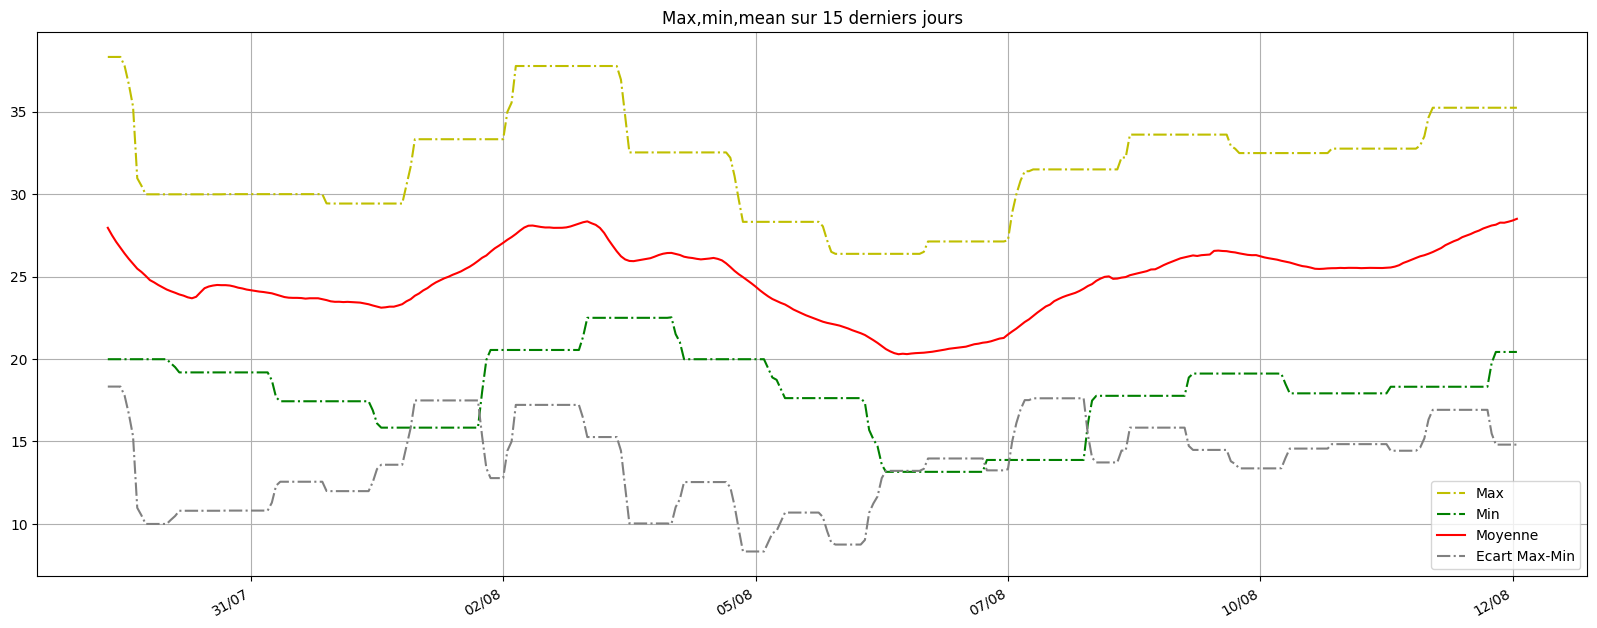

In [699]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(20, 8)
x = h[:-24]
plt.title(f"Max,min,mean sur {days} derniers jours")
plt.plot(x,max_days,"y-.",label="Max")
plt.plot(x,min_days,"g-.",label="Min")
plt.plot(x,mean_days,'r',label="Moyenne")
plt.plot(x,ecart_days,'-.',color='grey',label="Ecart Max-Min")
#plt.plot(t[l:l+window])
format_date(interval)
plt.legend()

In [700]:
#delta = [j-i for i, j in zip(mean_week[:-1], mean_week[1:])]
delta = np.diff(mean_days)
#delta

## Delta/days des moyennes 24h avec un glissement d'une heure

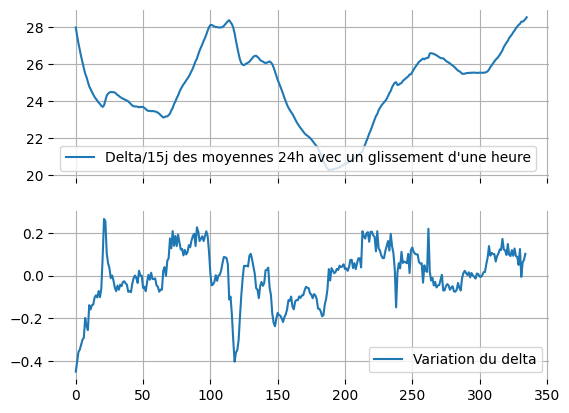

In [701]:
#fig,ax =plt.subplots(nrows=2)
#fig,ax =plt.subplots(nrows=2, sharex=True)
fig,ax =plt.subplots(nrows=2, sharex=True, subplot_kw=dict(frameon=False))
ax[0].plot(mean_days,label='Delta/'+str(days)+'j des moyennes 24h avec un glissement d\'une heure')
ax[1].plot(delta,label=('Variation du delta'))
ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend()


In [702]:
def local_min_max(liste):
    """
    Trouve les minima et maxima locaux d'une liste.

    Args:
    liste: La liste à analyser.

    Returns:
    Les listes max et min.
    """

    max = []
    min = []

    if liste[0] > liste[1]:
        max.append(liste[0])
    elif liste[0] <= liste[1] :
        min.append(liste[0])

    for i in range(1, len(liste) - 1):
        if liste[i] > liste[i - 1] and liste[i] >= liste[i + 1]:
            max.append(liste[i])
        elif liste[i] <= liste[i - 1] and liste[i] < liste[i + 1]:
            min.append(liste[i])

    return max, min


liste = [10, 11, 15, 12, 9, 7, 8, 10, 13, 15, 18, 16, 12, 10, 7, 5, 6, 11, 14, 14]
max, min = local_min_max(liste)

max,min

([15, 18, 14], [10, 7, 5])

In [703]:
# graphical output...
from pylab import sign, diff # type: ignore


In [704]:
# plot graph with local max and min
def plot_data(x,data,lw=3):
    # find the indexes of maximas and the minimas
    #a = diff(sign(diff(data))).nonzero()[0] + 1 # local min+max
    b = (diff(sign(diff(data))) > 0).nonzero()[0] + 1 # local min
    c = (diff(sign(diff(data))) < 0).nonzero()[0] + 1 # local max
    print(b,len(b),c,len(c))
    # plot the curve
    plt.plot(x,data,lw=lw)
    #plot the maximas
    for v in b:
        plt.plot(x[v], data[v], "ob")
    #plot the minimas
    for v in c:
        plt.plot(x[v], data[v], "or")
    plt.grid()


[ 5 15] 2 [ 2 10 18] 3


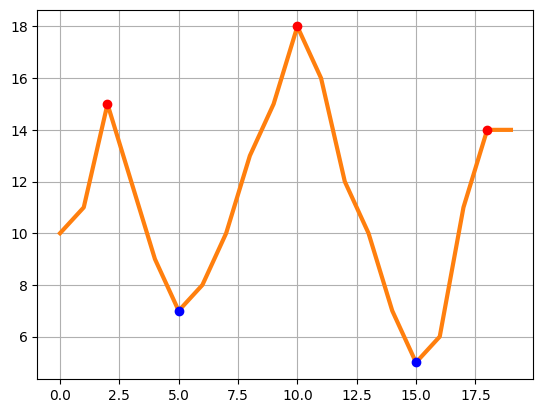

In [705]:
x = range(len(liste))
plt.plot(liste)
plot_data(x,liste)

In [706]:
jours = 7
data['heures']=[k.split(' ')[1].split(':')[0] for k in data.dates]
data['jours']=[k.split(' ')[0] for k in data.dates]

data.tail(24*jours)[['jours','heures','temp','variation']]

,jours,heures,temp,variation
20090,06/08/26,15,25.82,0.56
20091,06/08/26,16,26.10,0.28
20092,06/08/26,17,26.38,0.28
20093,06/08/26,18,25.94,-0.44
20094,06/08/26,19,25.14,-0.80
...,...,...,...,...
20253,13/08/26,10,26.00,1.43
20254,13/08/26,11,28.45,2.45
20255,13/08/26,12,31.26,2.81
20256,13/08/26,13,33.75,2.49


In [707]:
_min_ = round(data.tail(24*jours).temp.min(),2)
_max_ = round(data.tail(24*jours).temp.max(),2)

In [708]:
_max_ - _min_

np.float64(22.150000000000002)

In [709]:
window_start

'29/07/2026, 14:11:41'

## Main graph

(np.float64(25.099361111111133), 15)

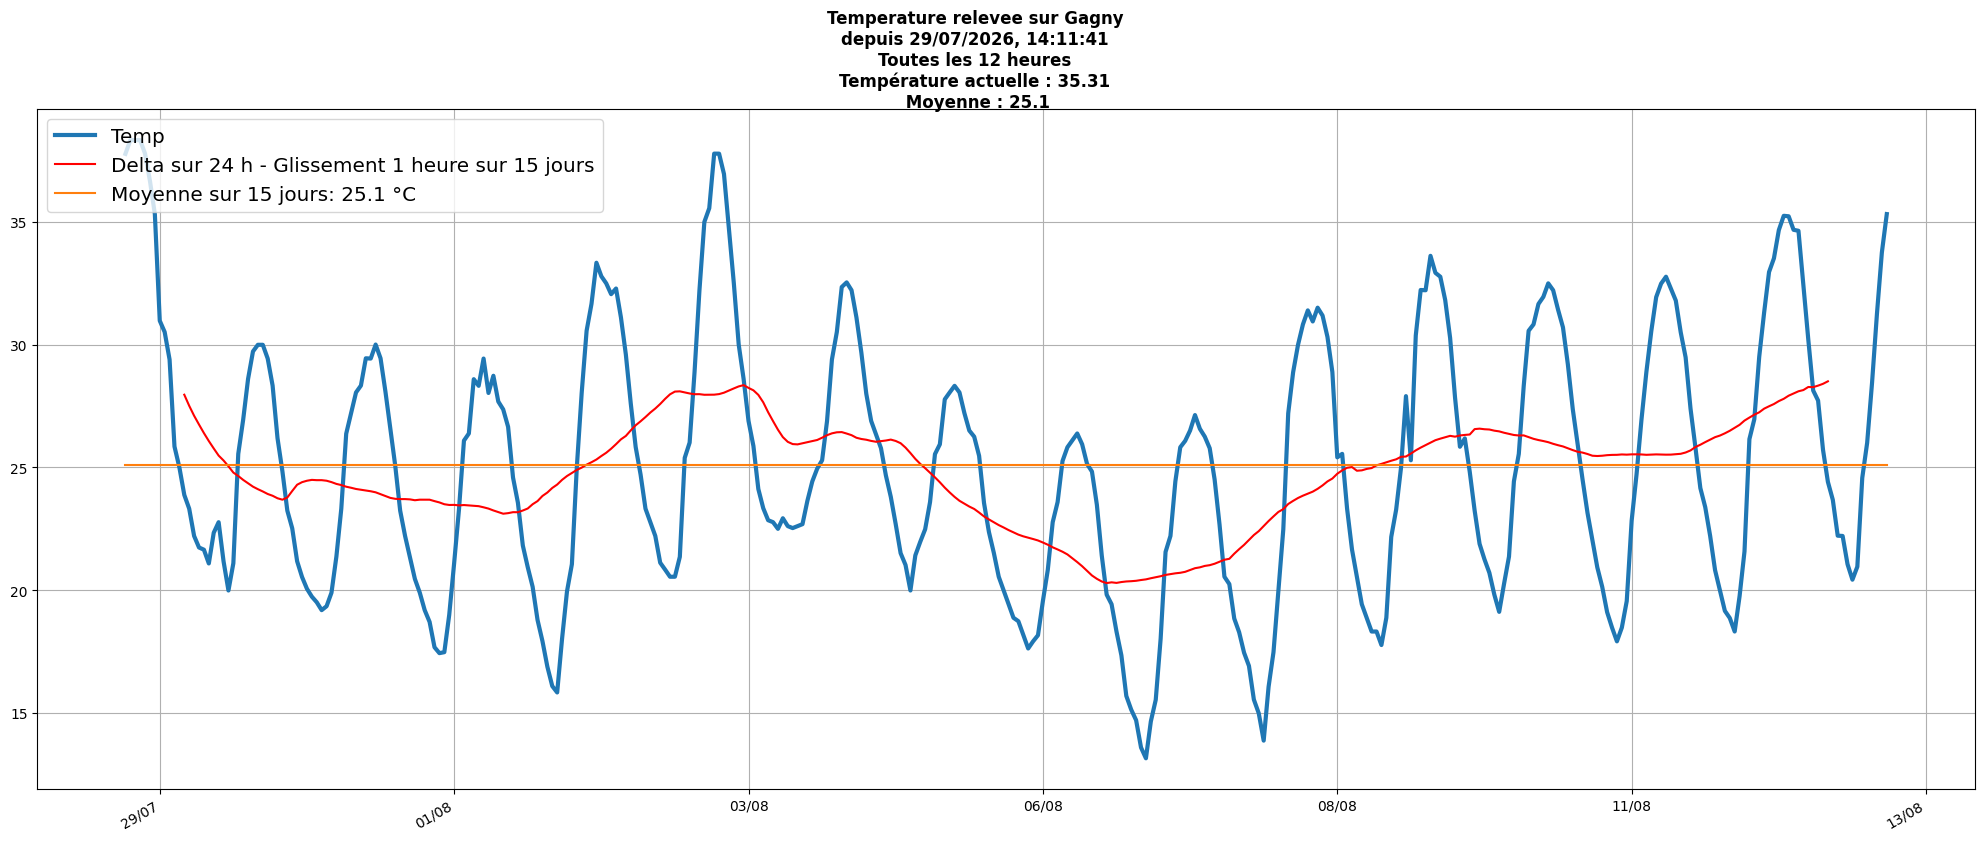

In [710]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(25, 10)
ax.set_xticklabels(hours,fontsize=10)
fig.suptitle(f"Temperature relevee sur Gagny\n\
depuis {window_start}\n\
Toutes les {interval} heures\nTempérature actuelle : {round(t.tail(1).values[0],2)}\n Moyenne : {round(moyenne,2)}", fontsize = 12, fontweight ='bold') 
#ax.xaxis.set_major_locator(mdates.DayLocator()) 
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
# plt.gca().xaxis.set_major_locator(mdates.HourLocator(range(0, 24, interval))) #interval=6))
# plt.gcf().autofmt_xdate()
format_date(interval)
plt.plot(h,t,label='Temp',lw=3)
plt.plot(h[h_w:len(t)-h_w],mean_days,'r-',label=f'Delta sur {window} h - Glissement 1 heure sur {days} jours')
h1 = h.head(1)
h2 = h.tail(1)
moy = round(moyenne,2)
plt.plot((h1,h2),(moyenne, moyenne),label=f'Moyenne sur {days} jours: {moy} °C')
#plt.grid()
plt.legend(loc=2,fontsize='x-large')
#plt.title('Current temp : '+str(current.temp)+' °C')

moyenne,days

In [711]:
data.tail(5)[['heures','temp','variation']]

,heures,temp,variation
20253,10,26.00,1.43
20254,11,28.45,2.45
20255,12,31.26,2.81
20256,13,33.75,2.49
20257,14,35.31,1.56


In [712]:
def area(df,dx=1):
    return (sum(df[:len(df)-1])+sum(df[1:len(df)]))*dx/2
df=[0,1]
area(df,1)

0.5

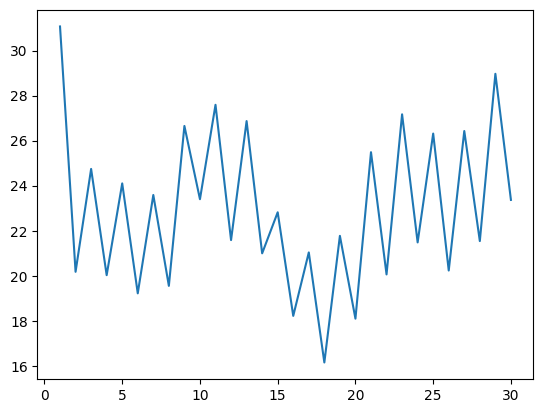

In [713]:
s = list(t)
# area under temperature
a=[]
for k in range(0,len(s),h_w):
    a.append(area(s[k:k+h_w])/h_w)
x = np.array(range(1,len(a)+1))
plt.plot(x,a)

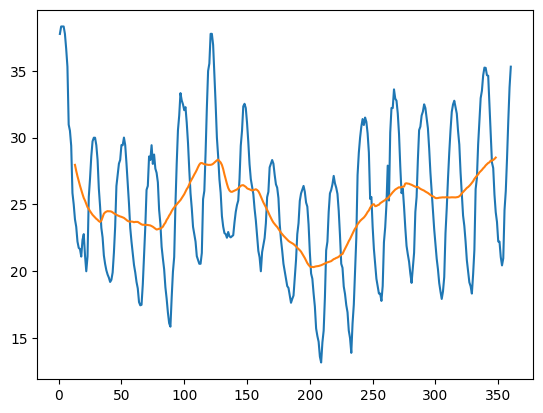

In [714]:
x = np.array(range(1,len(t)+1))
area(t)

plt.plot(x,t)
plt.plot(x[h_w:len(x)-h_w],mean_days)

(1.9500000000000002, [<matplotlib.lines.Line2D at 0x2058c32d450>])

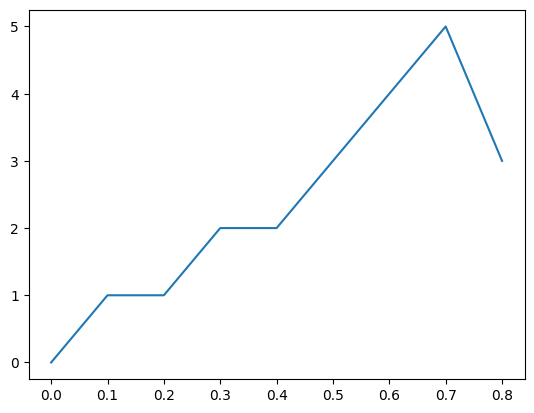

In [715]:
df = [0,1,1,2,2,3,4,5,3]
dx = .1
x = np.array(range(len(df)))
area(df,dx),plt.plot(x*dx,df)


(-0.35000000000000003, [<matplotlib.lines.Line2D at 0x20585fa3c50>])

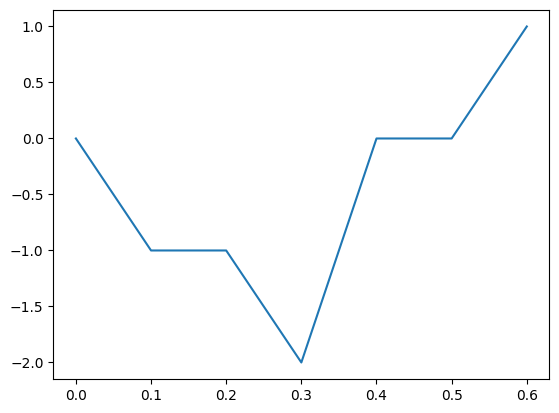

In [716]:
# valeurs négatives
dx = 0.1
df = [0,-1,-1,-2,0,0,1]
x = np.array(range(len(df)))
area(df,dx),plt.plot(x*dx,df)

In [717]:
n = data.tail(1)['dates'].values[0]
n, type(n)

('13/08/26 14:00:00', str)

In [718]:
def days_hours_minutes(td):
    return td.days, td.seconds//3600, (td.seconds//60)%60

In [719]:
savefig = False
ref = '07/08/25 07:00:00'
datetime_object = datetime.strptime(ref, '%d/%m/%y %H:%M:%S')
datetime_object

datetime.datetime(2025, 8, 7, 7, 0)

In [720]:
def get_next_save_date(ref_date, current_date=None):
    global savefig
    """
    Calculate the next save date (every 7 days from reference date).
    
    Args:
        ref_date (datetime): The reference start date
        current_date (datetime, optional): Date to check from. Defaults to now.
    
    Returns:
        savefig : update flag
        datetime: Next save date
    """
    if current_date is None:
        current_date = datetime.now()
    
    delta = current_date - ref_date
    days_since_last_save = delta.days % 7
    print(days_since_last_save)
    if days_since_last_save == 0:
        print("Save the figure")
        savefig = True
        return current_date
    else:
        return current_date + dt.timedelta(days=(7 - days_since_last_save))


In [721]:
# Example usage
next_save = get_next_save_date(datetime_object)
print(savefig)
print(f"Next save will be on: {next_save.strftime('%d/%m/%y')}")
td = datetime.now() - datetime_object
if savefig:
    print("Save figure")
else:
    print("No saving today")

0
Save the figure
True
Next save will be on: 13/08/26
Save figure


In [722]:
ref, td, td.days%7, days_hours_minutes(td)

('07/08/25 07:00:00',
 datetime.timedelta(days=371, seconds=25912, microseconds=164341),
 0,
 (371, 7, 11))

In [723]:
end = time.time()
print(end - begin)

34.2195885181427


In [724]:
savefig

True

In [725]:
data.tail(15)  # 02/01/2026 22h index 14918 à recopier vers temp02012026.csv

,temp,hours,dates,variation,heures,jours
20243,27.72,20678.000000,13/08/26 00:00:00,-0.41,00,13/08/26
20244,25.72,20678.041667,13/08/26 01:00:00,-2.00,01,13/08/26
20245,24.41,20678.083333,13/08/26 02:00:00,-1.31,02,13/08/26
20246,23.68,20678.125000,13/08/26 03:00:00,-0.73,03,13/08/26
20247,22.22,20678.166667,13/08/26 04:00:00,-1.46,04,13/08/26
20248,22.21,20678.208333,13/08/26 05:00:00,-0.01,05,13/08/26
20249,21.06,20678.250000,13/08/26 06:00:00,-1.15,06,13/08/26
20250,20.43,20678.291667,13/08/26 07:00:00,-0.63,07,13/08/26
20251,20.96,20678.333333,13/08/26 08:00:00,0.53,08,13/08/26
20252,24.57,20678.375000,13/08/26 09:00:00,3.61,09,13/08/26


# Température depuis 15 jours par heure

In [726]:
today = datetime.now()
today_str = today.strftime('%d/%m/%y %H:%M:%S')

In [727]:
data.tail(1)["dates"].values[0].split(':')[0], today_str.split(':')[0]


('13/08/26 14', '13/08/26 14')

### test de validité de data !

#### vérification de ligne de données manquantes

In [728]:
difference_heures = int(data.tail(1)["dates"].values[0].split(' ')[1].split(':')[0]) - int(today_str.split(' ')[1].split(':')[0])   
difference_heures

0

In [729]:
assert data.tail(1)["dates"].values[0].split(':')[0] == today_str.split(':')[0]

In [730]:
jours = 15

In [731]:
# liste des températures sur une même plage horaire de 24h des 7 derniers jours
data_24_list = [list([data.tail(24*t).temp.head(24).values]) for t in range(jours, 0, -1)]
data_24_list

[[array([37.76, 38.32, 38.32, 38.32, 37.77, 36.66, 35.31, 30.97, 30.51,
         29.39, 25.85, 25.  , 23.88, 23.32, 22.21, 21.74, 21.65, 21.09,
         22.34, 22.77, 21.18, 19.99, 21.1 , 25.55])],
 [array([26.94, 28.6 , 29.72, 29.99, 29.99, 29.43, 28.33, 26.19, 24.84,
         23.24, 22.52, 21.18, 20.54, 20.06, 19.74, 19.51, 19.19, 19.35,
         19.9 , 21.37, 23.32, 26.37, 27.21, 28.05])],
 [array([28.33, 29.44, 29.43, 30.  , 29.44, 28.08, 26.57, 25.06, 23.24,
         22.21, 21.33, 20.46, 19.9 , 19.19, 18.71, 17.68, 17.44, 17.48,
         19.  , 21.1 , 23.32, 26.09, 26.38, 28.59])],
 [array([28.32, 29.43, 28.03, 28.73, 27.68, 27.36, 26.65, 24.59, 23.56,
         21.82, 20.94, 20.14, 18.79, 17.93, 16.89, 16.1 , 15.84, 18.03,
         19.95, 21.06, 24.99, 28.04, 30.56, 31.66])],
 [array([33.33, 32.78, 32.49, 32.05, 32.28, 31.1 , 29.59, 27.6 , 25.83,
         24.71, 23.32, 22.77, 22.21, 21.12, 20.84, 20.55, 20.55, 21.36,
         25.39, 26.01, 28.88, 32.21, 34.99, 35.55])],
 [array([3

### moyenne sur la même plage de 24h sur ...

In [732]:
print(jours, 'jours')

15 jours


In [733]:
# Add all arrays element-wise
sum_array = np.sum(data_24_list, axis=0)

# Divide by jours to get mean
mean_array = sum_array / jours

print("Sum array:", sum_array)
print("Mean array:", mean_array)

Sum array: [[461.92 470.45 473.87 470.19 461.59 448.54 428.43 395.17 374.74 358.91
  339.53 325.15 311.23 300.24 291.34 282.55 275.42 288.34 311.68 338.69
  365.26 399.28 418.14 445.11]]
Mean array: [[30.79466667 31.36333333 31.59133333 31.346      30.77266667 29.90266667
  28.562      26.34466667 24.98266667 23.92733333 22.63533333 21.67666667
  20.74866667 20.016      19.42266667 18.83666667 18.36133333 19.22266667
  20.77866667 22.57933333 24.35066667 26.61866667 27.876      29.674     ]]


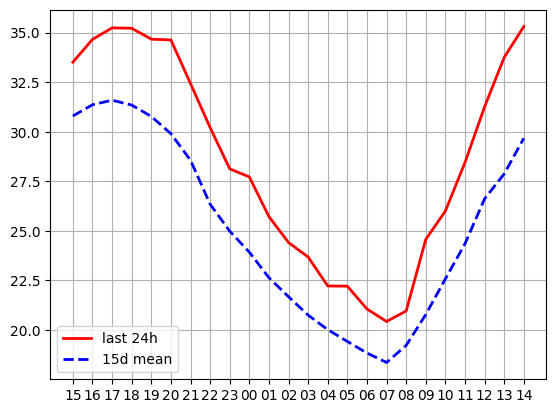

In [734]:
lw = 1
all = False
for t in range(jours,0,-1):
    #if t==1: lw=4
    if t==1:
        plt.plot(data.tail(24*t).heures.head(24),data.tail(24*t).temp.head(24),lw=lw+1,label='last 24h',c='red')
        plt.plot(range(24),mean_array[0],lw=lw+1,label='15d mean',c='blue',ls='--')
    elif all:
        plt.plot(range(24),data_24_list[t-1][0],lw=lw,label=-t)
plt.legend()
plt.grid()

### courbes de températures journalières superposées 
### 15 jours


In [735]:
jours

15

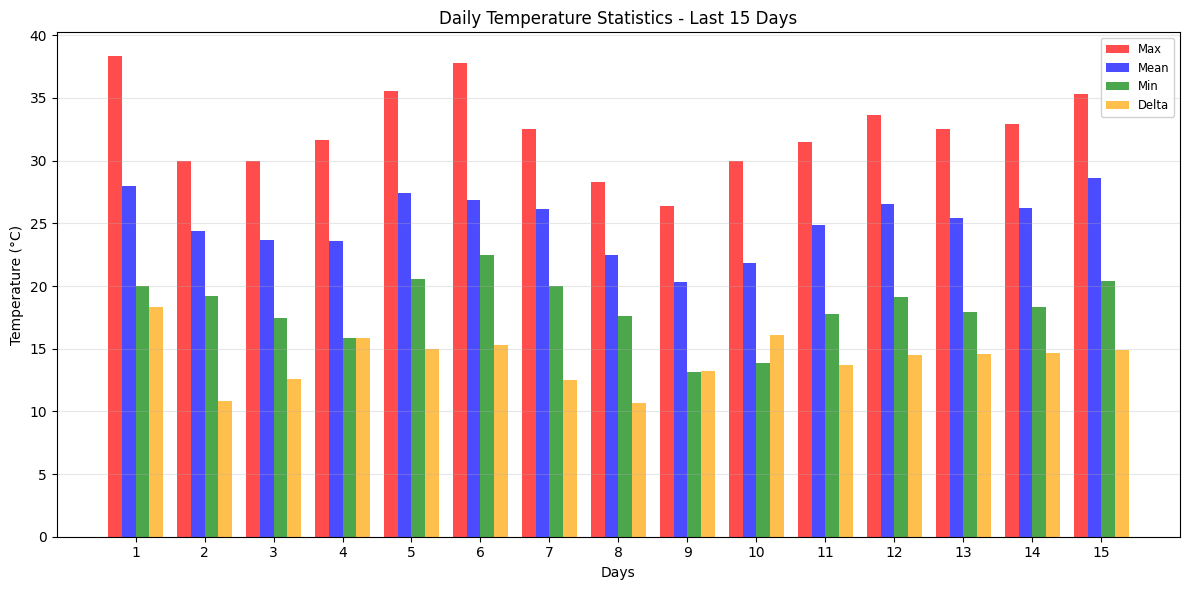

In [736]:
# Create a summary dataframe with daily statistics
df1 = pd.DataFrame({
    'high': [data.tail(24*t).temp.head(24).max() for t in range(jours, 0, -1)],
    'low': [data.tail(24*t).temp.head(24).min() for t in range(jours, 0, -1)],
    'moy': [data.tail(24*t).temp.head(24).mean() for t in range(jours, 0, -1)],
    'delta': [data.tail(24*t).temp.head(24).max() - data.tail(24*t).temp.head(24).min() for t in range(jours, 0, -1)]
})

# Plot the daily statistics
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(df1))
width = 0.2

ax.bar(x_pos - width*1.5, df1['high'], width, label='Max', color='red', alpha=0.7)
ax.bar(x_pos - width/2, df1['moy'], width, label='Mean', color='blue', alpha=0.7)
ax.bar(x_pos + width/2, df1['low'], width, label='Min', color='green', alpha=0.7)
ax.bar(x_pos + width*1.5, df1['delta'], width, label='Delta', color='orange', alpha=0.7)

ax.set_xlabel('Days')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Daily Temperature Statistics - Last {jours} Days')
ax.set_xticks(x_pos)
ax.set_xticklabels(range(1, len(df1)+1))
ax.legend()
ax.legend(fontsize='small', loc='best', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 15 days temperature

Fig saved


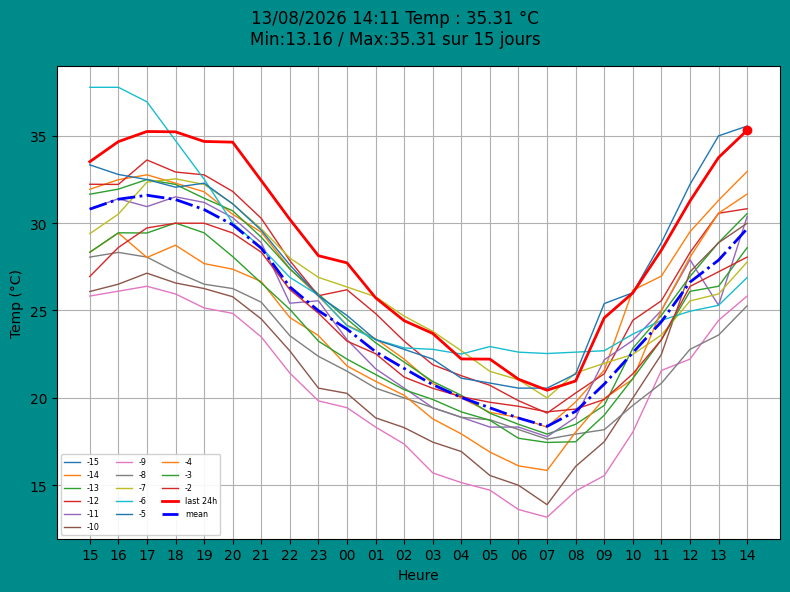

In [737]:
fig, ax = plt.subplots(figsize=(8, 6),facecolor='darkcyan')
#lw = 1
datetime_object = datetime.now()
for t in range(jours,0,-1):
    #if t==1: lw=4
    x = data.tail(24*t).heures.head(24)
    if t==1:
        plt.plot(x,data.tail(24*t).temp.head(24),lw=lw+1,label='last 24h',c='red')
        #plt.plot(x,data_24_list[t-1][0],lw=lw+1,label=-t,c='red')
        plt.plot(x,mean_array[0],lw=lw+1,label='mean',c='blue',ls='-.')
    else:
        #plt.plot(x,data.tail(24*t).temp.head(24),lw=lw,label=-t)
        plt.plot(x,data_24_list[t-1][0],lw=lw,label=-t)

plt.plot(data.tail(1).heures,data.tail(1).temp,'ro')
fig.suptitle(f"{datetime_object.strftime('%d/%m/%Y %H:%M')} Temp : {round(data.tail(1).temp.values[0],2)} °C\nMin:{_min_} / Max:{_max_} sur {jours} jours")
plt.xlabel(f"Heure")
plt.ylabel("Temp (°C)")
plt.grid()
# Valid font size are xx-small, x-small, small, medium, large, x-large, xx-large, larger, smaller, None
plt.legend(fontsize='xx-small', loc='best', ncol=3,framealpha=0.9)

#savefig = True
# save figure if needed
if savefig:
    fig_filename = next_save.strftime('%Y%m%d') + '_7daystemp.png'
    plt.savefig(fig_filename)
    print('Fig saved')
else:
    print('Next save date:', next_save.strftime('%d/%m/%Y %H:%M'))

plt.tight_layout()
plt.show()

In [738]:
data['temp'].tail(24*jours).describe()

count    360.000000
mean      25.099361
std        5.346927
min       13.160000
25%       21.012500
50%       24.835000
75%       28.957500
max       38.320000
Name: temp, dtype: float64

<Axes: ylabel='Density'>

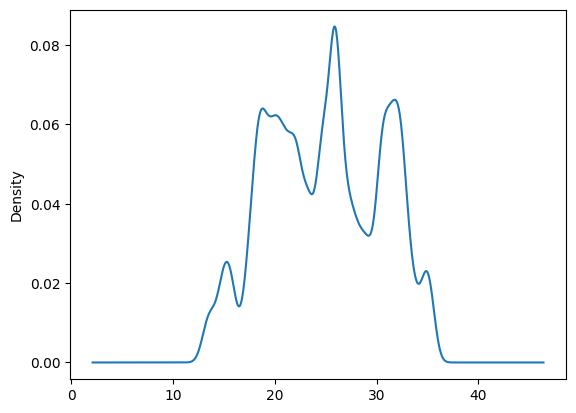

In [739]:
_7days = data['temp'].tail(24*7)
#_7days.hist(bins=20, width=0.5, alpha=0.7)
_7days.plot.kde(bw_method=0.1)


<Axes: >

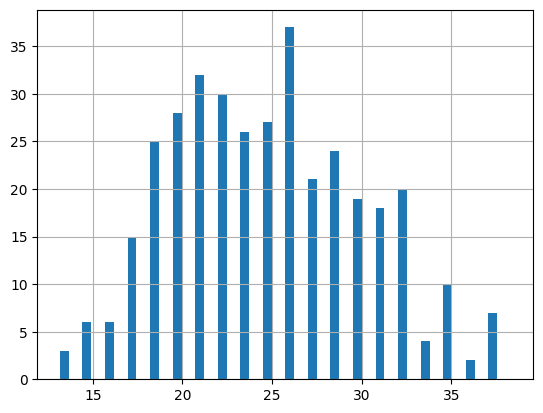

In [740]:
_7days = data['temp'].tail(24*jours)
_7days.hist(bins=20,width=0.5)

In [741]:
print('Min:', _7days.min(), ', Max:', _7days.max(), ', Mean:', _7days.mean())

Min: 13.160000000000023 , Max: 38.32000000000005 , Mean: 25.099361111111133


In [742]:
t=7
max_, min_ = np.max(list(data.tail(24*t).temp.head(24))), np.min(list(data.tail(24*t).temp.head(24)))
print(max_,min_)

26.379999999999995 13.160000000000023


In [743]:
df_jours=data.tail(24*7)
df

[0, -1, -1, -2, 0, 0, 1]

In [744]:
df_jours.groupby('jours')['temp'].mean()

jours
06/08/26    24.324444
07/08/26    20.654583
08/08/26    23.510000
09/08/26    25.442917
10/08/26    26.302500
11/08/26    25.526667
12/08/26    27.242083
13/08/26    25.850000
Name: temp, dtype: float64

<Axes: xlabel='jours'>

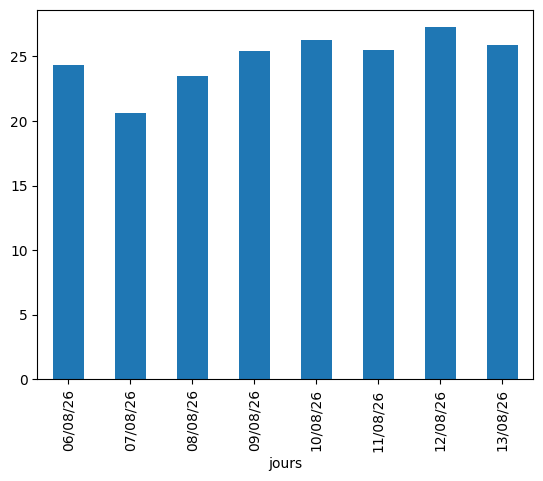

In [745]:
df_jours.groupby('jours')['temp'].mean().plot(kind='bar')

In [746]:
csv_file1

'Y:\\Documents\\temp03062024.csv'

# Save to CSV

In [747]:
save = False
# save to csv 
if save : 
    if csv_file1 == r"Y:\Documents\temp03062024.csv":
        csv_file = r"../data_temp03062024.csv"  
    else:
        csv_file = r"../data_temp02012026.csv"  # 02/01/2026 22h
    to_csv(csv_file, data)

In [748]:
# how to stop here

class StopExecution(Exception):
    def _render_traceback_(self):
        return []
#raise StopExecution

#raise
#assert(False)
#raise KeyboardInterrupt
#ext  # create an error

import this
#dir(list)
#dir(str)

# how to label on top of a bar plot

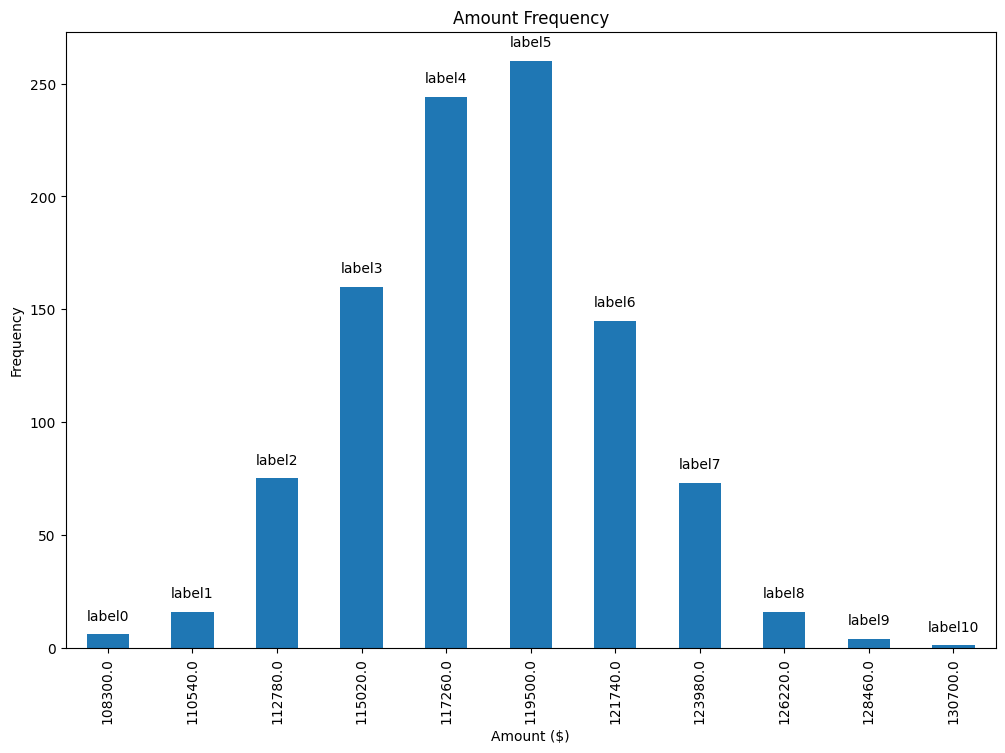

In [749]:
# Bring some raw data.
frequencies = [6, 16, 75, 160, 244, 260, 145, 73, 16, 4, 1]
# In my original code I create a series and run on that,
# so for consistency I create a series from the list.
freq_series = pd.Series(frequencies)

x_labels = [
    108300.0,
    110540.0,
    112780.0,
    115020.0,
    117260.0,
    119500.0,
    121740.0,
    123980.0,
    126220.0,
    128460.0,
    130700.0,
]

# Plot the figure.
plt.figure(figsize=(12, 8))
ax = freq_series.plot(kind="bar")
ax.set_title("Amount Frequency")
ax.set_xlabel("Amount ($)")
ax.set_ylabel("Frequency")
ax.set_xticklabels(x_labels)

rects = ax.patches

# Make some labels.
labels = [f"label{i}" for i in range(len(rects))]

for rect, label in zip(rects, labels):
    height = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + 5, label, ha="center", va="bottom"
    )

plt.show()

In [750]:
areas = []
moys = []
x = []
for t in range(jours,0,-1):
    x.append(-t)
    a = area(data.tail(24*t+1).temp.head(25))    # calcul sur 24h
    areas.append(round(a/24,2))
    moys.append(round(data.tail(24*t+1).temp.head(25).mean(),2))
    #print(-t,a)
#print(areas,x)
len(data.tail(24*t+1)),moys

(25,
 [np.float64(28.31),
  np.float64(24.45),
  np.float64(23.86),
  np.float64(23.83),
  np.float64(27.57),
  np.float64(27.23),
  np.float64(26.16),
  np.float64(22.66),
  np.float64(20.55),
  np.float64(22.01),
  np.float64(25.08),
  np.float64(26.73),
  np.float64(25.68),
  np.float64(26.4),
  np.float64(28.78)])

In [751]:
data

,temp,hours,dates,variation,heures,jours
0,13.19,19834.541667,21/04/24 13:00:00,NaN,13,21/04/24
1,12.20,19834.583333,21/04/24 14:00:00,-0.99,14,21/04/24
2,12.29,19834.625000,21/04/24 15:00:00,0.09,15,21/04/24
3,12.42,19834.666667,21/04/24 16:00:00,0.13,16,21/04/24
4,14.54,19834.708333,21/04/24 17:00:00,2.12,17,21/04/24
...,...,...,...,...,...,...
20253,26.00,20678.416667,13/08/26 10:00:00,1.43,10,13/08/26
20254,28.45,20678.458333,13/08/26 11:00:00,2.45,11,13/08/26
20255,31.26,20678.500000,13/08/26 12:00:00,2.81,12,13/08/26
20256,33.75,20678.541667,13/08/26 13:00:00,2.49,13,13/08/26


In [752]:
areas


[28.19,
 24.35,
 23.68,
 23.56,
 27.32,
 27.06,
 26.11,
 22.5,
 20.35,
 21.76,
 24.87,
 26.57,
 25.47,
 26.18,
 28.55]

[Text(-8.0, 0, '-7'),
 Text(-6.0, 0, '-6'),
 Text(-4.0, 0, '-5'),
 Text(-2.0, 0, '-4'),
 Text(0.0, 0, '-3'),
 Text(2.0, 0, '-2'),
 Text(4.0, 0, '-1'),
 Text(6.0, 0, '0'),
 Text(8.0, 0, '1')]

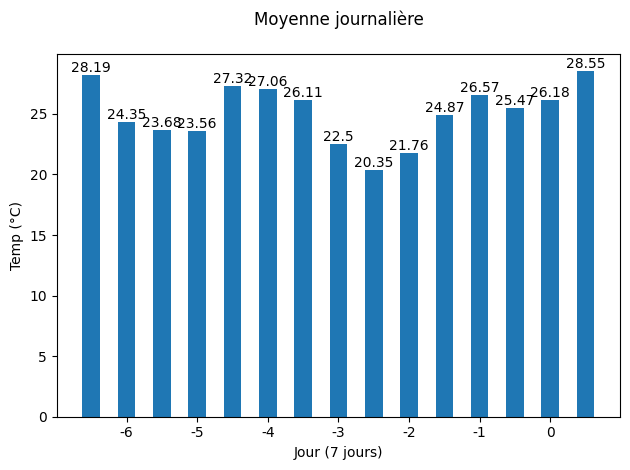

In [753]:
X_axis = np.arange(len(x))-7
fig, ax = plt.subplots()
plt.title("Moyenne journalière\n")
plt.xlabel("Jour (7 jours)")
plt.ylabel("Temp (°C)")
#plt.plot(x,areas,"r")
plt.bar(X_axis,areas,width=0.5)
fig.tight_layout()
# plt.bar(X_axis-0.3,areas,width=0.1)
# plt.bar(X_axis+0.3,moys,width=0.1)
rects = ax.patches

# Make some labels.
labels = [rects[i].get_height() for i in range(len(rects))]

for rect, label in zip(rects, labels):
    height = rect.get_height()
    offset = sign(label)*0.1-0.1
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + offset, label, ha="center", va="bottom"
    )
ax.set_xticklabels(X_axis)


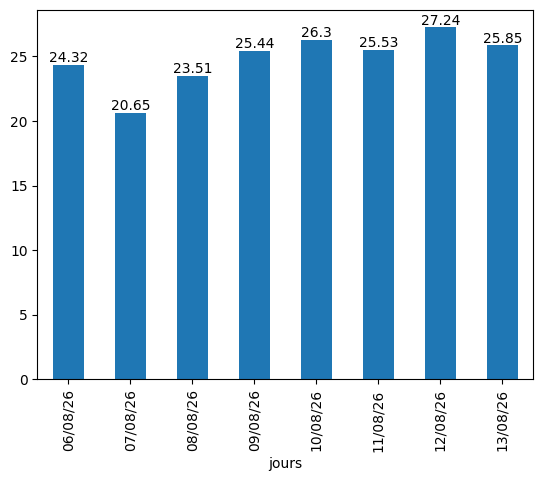

In [754]:
fig, ax = plt.subplots()
df_jours.groupby('jours')['temp'].mean().plot(kind='bar')
rects = ax.patches

# Make some labels.
labels = [round(rects[i].get_height(),2) for i in range(len(rects))]

for rect, label in zip(rects, labels):
    height = rect.get_height()
    offset = sign(label)*0.1-0.1
    ax.text(
        rect.get_x() + rect.get_width() / 2, height + offset, label, ha="center", va="bottom"
    )


In [755]:
labels

[np.float64(24.32),
 np.float64(20.65),
 np.float64(23.51),
 np.float64(25.44),
 np.float64(26.3),
 np.float64(25.53),
 np.float64(27.24),
 np.float64(25.85)]

In [756]:
df = list(data.tail(24).temp.head(24))
df,area(df)

([33.51000000000005,
  34.660000000000025,
  35.24000000000001,
  35.22000000000003,
  34.670000000000016,
  34.629999999999995,
  32.43000000000001,
  30.21000000000004,
  28.129999999999995,
  27.720000000000027,
  25.720000000000027,
  24.410000000000025,
  23.680000000000007,
  22.220000000000027,
  22.21000000000004,
  21.06,
  20.430000000000007,
  20.96000000000004,
  24.57000000000005,
  26.0,
  28.450000000000045,
  31.260000000000048,
  33.75,
  35.31],
 652.0400000000005)

In [757]:
moy = []
for i in range(len(df)-1):
    moy.append((df[i]+df[i+1])/2)
sum(moy)

652.0400000000004

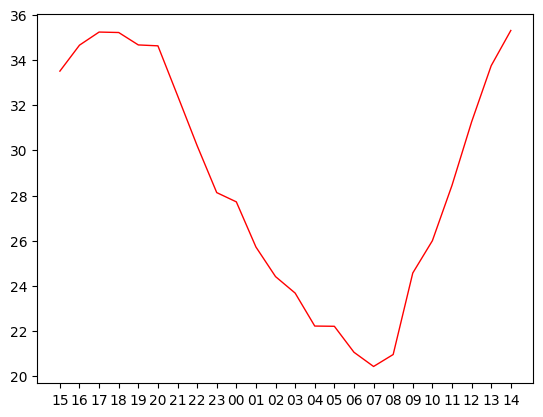

In [758]:
plt.plot(data.tail(24).heures.head(24),data.tail(24).temp.head(24),lw=lw,label=-t,c='red')

In [759]:
data.tail()


,temp,hours,dates,variation,heures,jours
20253,26.00,20678.416667,13/08/26 10:00:00,1.43,10,13/08/26
20254,28.45,20678.458333,13/08/26 11:00:00,2.45,11,13/08/26
20255,31.26,20678.500000,13/08/26 12:00:00,2.81,12,13/08/26
20256,33.75,20678.541667,13/08/26 13:00:00,2.49,13,13/08/26
20257,35.31,20678.583333,13/08/26 14:00:00,1.56,14,13/08/26


In [760]:
chop = data.tail(24).temp
_max, _min = local_min_max(list(chop))
_max,_min,len(_max),len(_min)

([35.24000000000001], [33.51000000000005, 20.430000000000007], 1, 2)

In [761]:
_diff=[M-m for M,m in zip(_max, _min)]

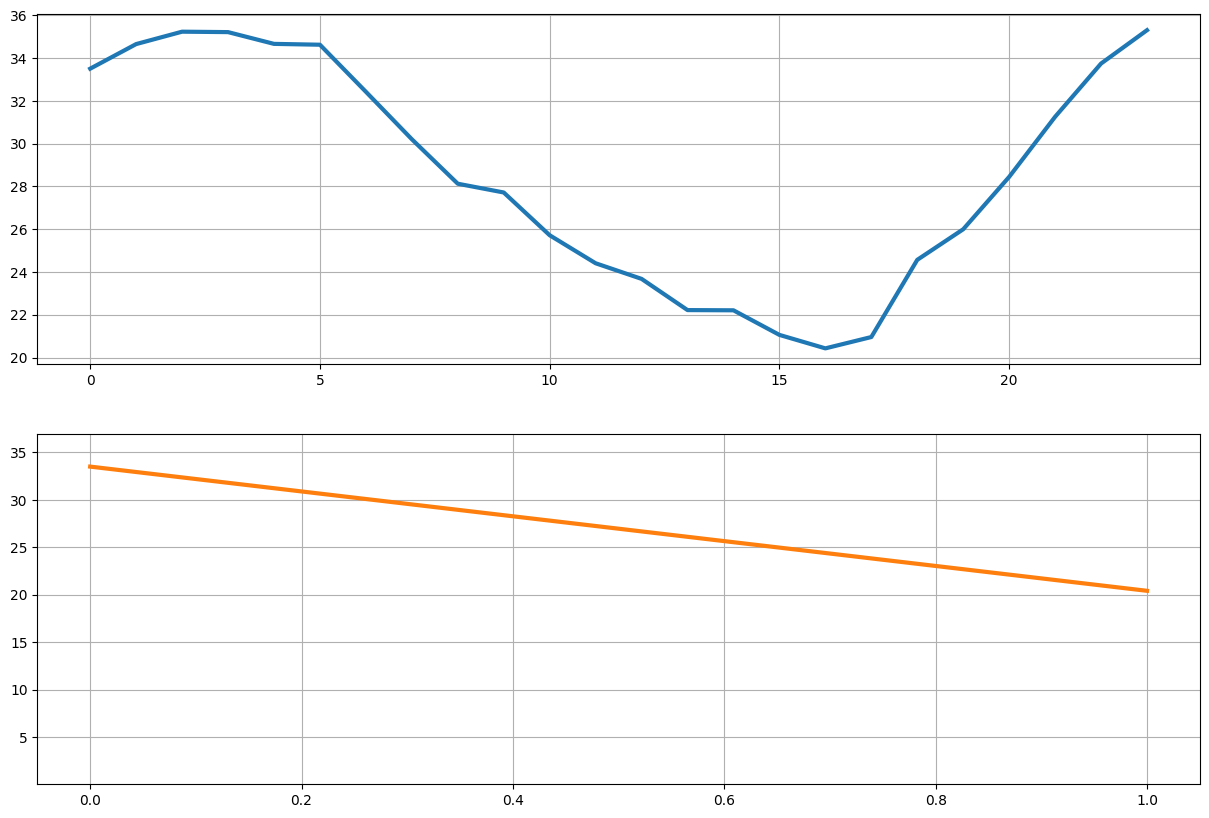

In [762]:
fig, (ax1,ax2) = plt.subplots(2,1)
# the size of A4 paper
fig.set_size_inches(15, 10)
ax1.plot(list(data.tail(24).temp),lw=3)
ax1.grid()
ax2.plot(_max,lw=3)
ax2.plot(_min,lw=3)
ax2.plot(_diff,'r-.',lw=3)
ax2.grid()

[] 0 [] 0
[] 0 [] 0


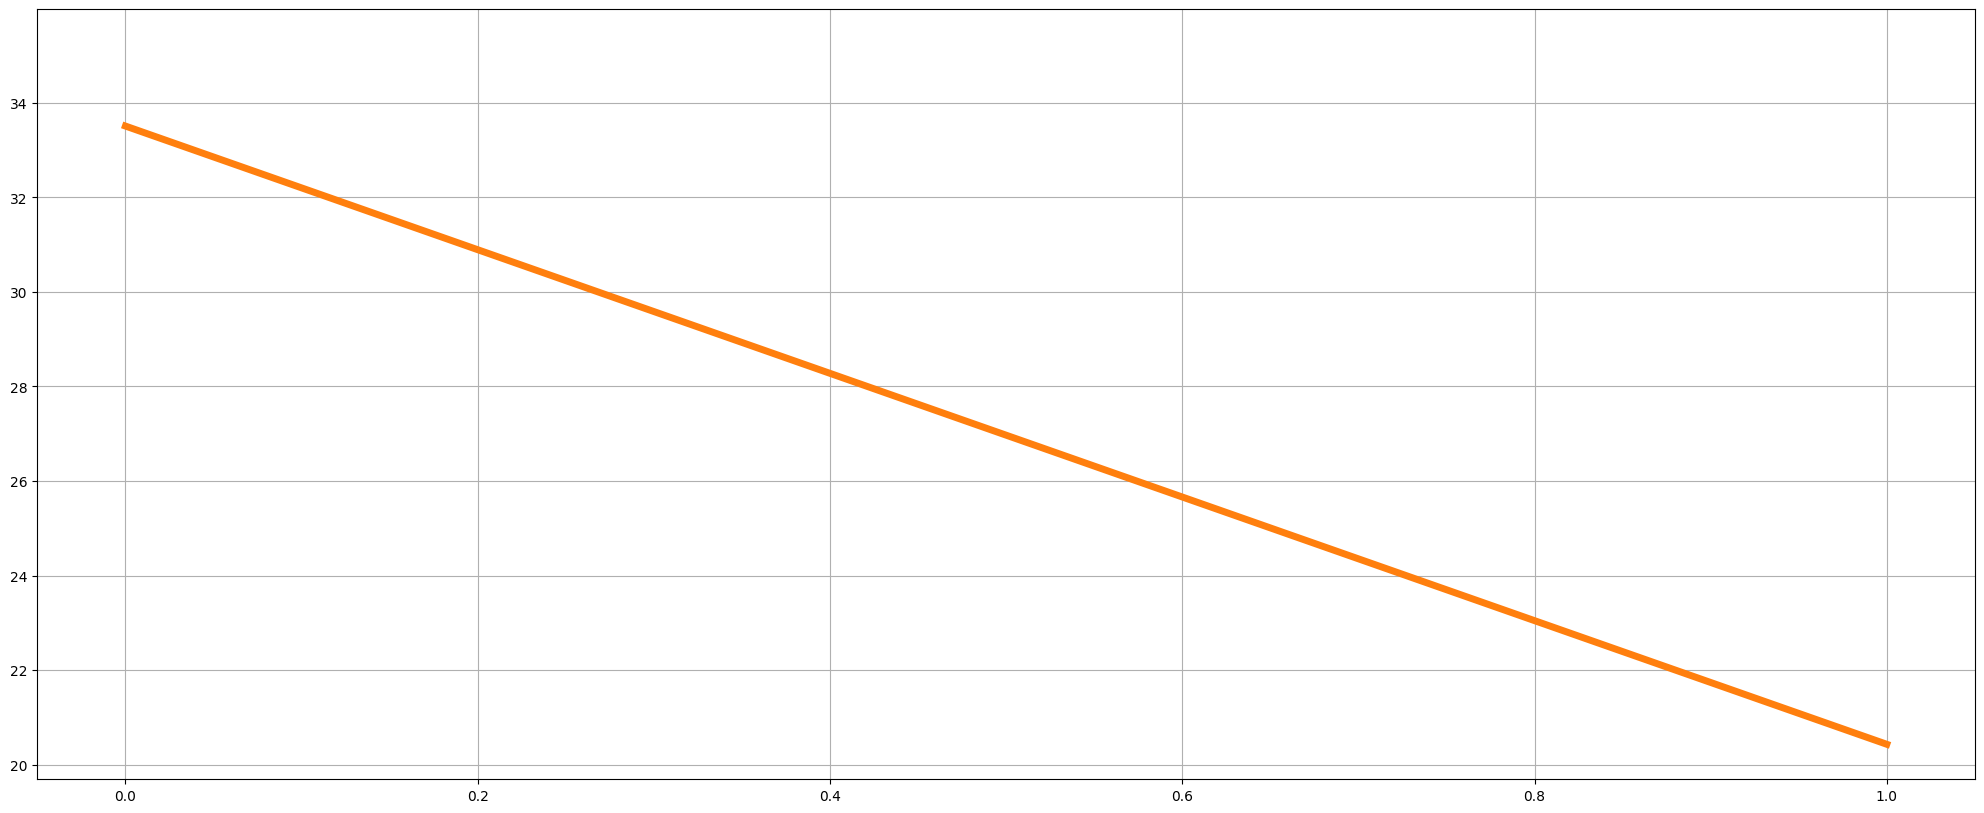

In [763]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(25, 10)
x =  range(len(_max))
plot_data(x,_max,lw=5)
x =  range(len(_min))
plot_data(x,_min,lw=5)
plt.grid()

In [764]:
liste = [10, 11, 15, 12, 9, 7, 8, 10, 13, 15, 18, 16, 12, 10, 7, 5, 6, 11, 14, 14]
diff(liste)


array([ 1,  4, -3, -3, -2,  1,  2,  3,  2,  3, -2, -4, -2, -3, -2,  1,  5,
        3,  0])

In [765]:
sign(diff(liste))


array([ 1,  1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1,
        1,  0])

In [766]:
diff(sign(diff(liste)))


array([ 0, -2,  0,  0,  2,  0,  0,  0,  0, -2,  0,  0,  0,  0,  2,  0,  0,
       -1])

In [767]:
diff(sign(diff(liste)))>0


array([False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False,  True, False, False, False])

In [768]:
(diff(sign(diff(liste)))).nonzero()

(array([ 1,  4,  9, 14, 17]),)

# maximas, minimas

[ 5 15] 2 [ 2 10 18] 3


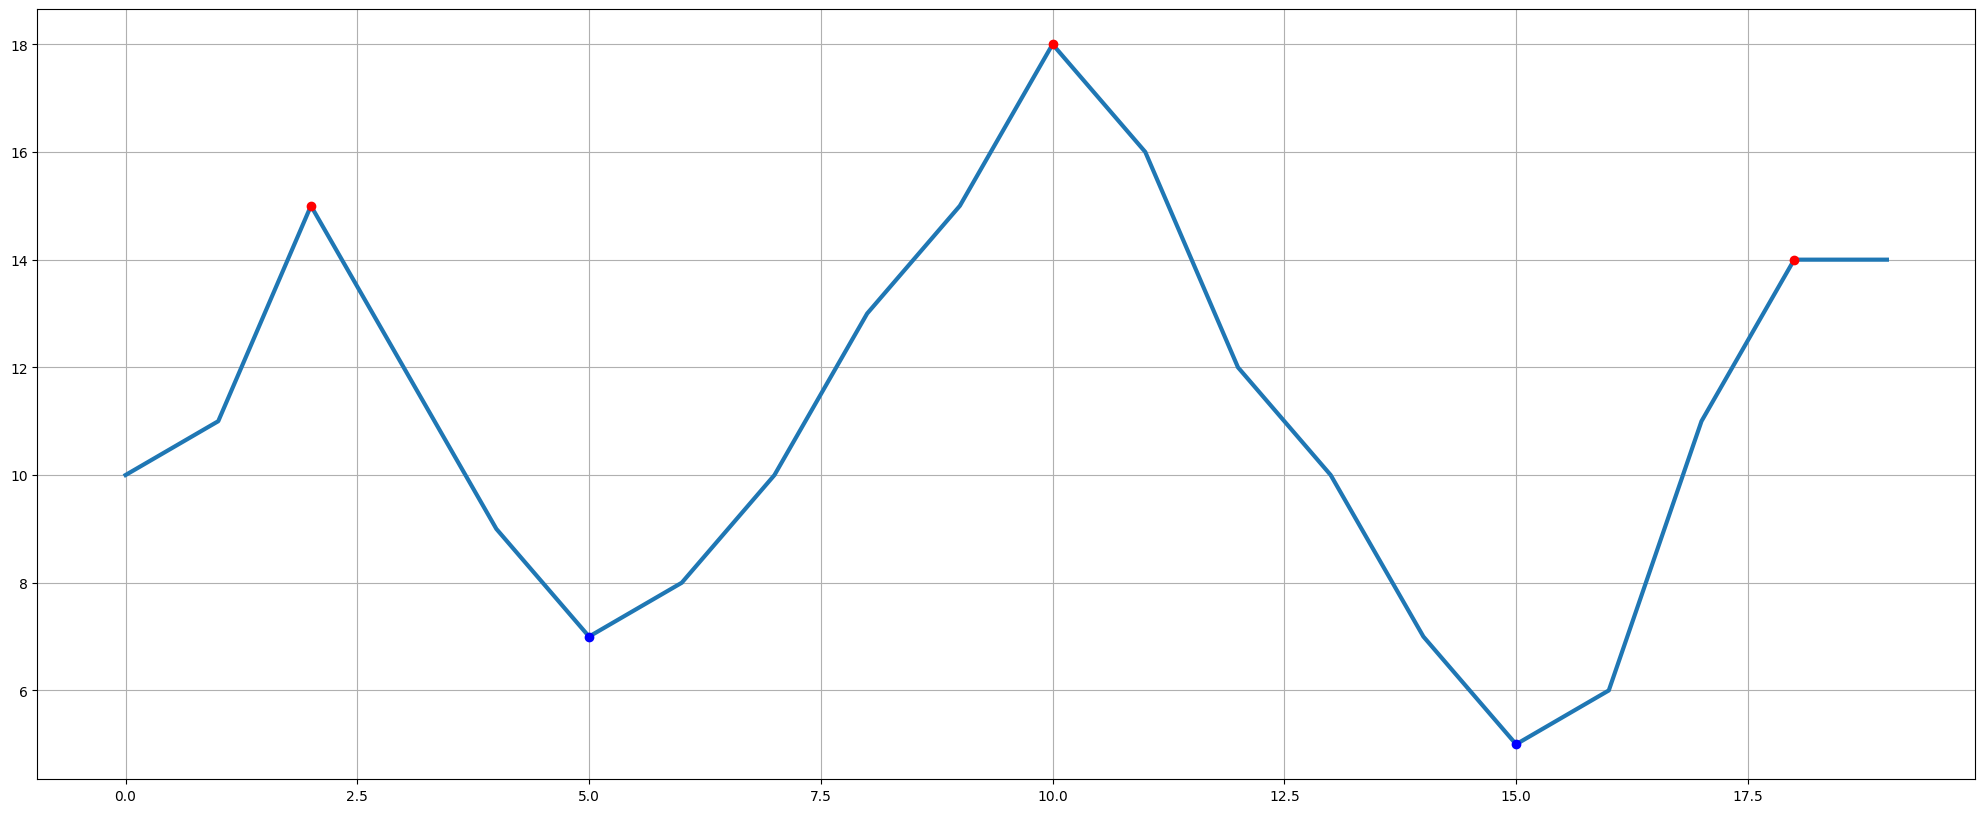

In [769]:
fig, ax = plt.subplots()
# the size of A4 paper
fig.set_size_inches(25, 10)
x = range(len(liste))
_data = liste
plot_data(x, _data)


In [770]:
date_time_str,days,interval

('21/04/24 13:00:00', 15, 12)

In [771]:
df

[33.51000000000005,
 34.660000000000025,
 35.24000000000001,
 35.22000000000003,
 34.670000000000016,
 34.629999999999995,
 32.43000000000001,
 30.21000000000004,
 28.129999999999995,
 27.720000000000027,
 25.720000000000027,
 24.410000000000025,
 23.680000000000007,
 22.220000000000027,
 22.21000000000004,
 21.06,
 20.430000000000007,
 20.96000000000004,
 24.57000000000005,
 26.0,
 28.450000000000045,
 31.260000000000048,
 33.75,
 35.31]

## last records

In [772]:
# 7 jours temp, mean
df = pd.DataFrame(data.tail(7*24)['temp'])
df['mean']= mean_days[-7*24:]
df

,temp,mean
20090,25.82,22.449583
20091,26.10,22.356667
20092,26.38,22.264167
20093,25.94,22.194583
20094,25.14,22.141667
...,...,...
20253,26.00,28.272500
20254,28.45,28.266250
20255,31.26,28.328333
20256,33.75,28.401667


# temperature, moyenne, variation

<Axes: >

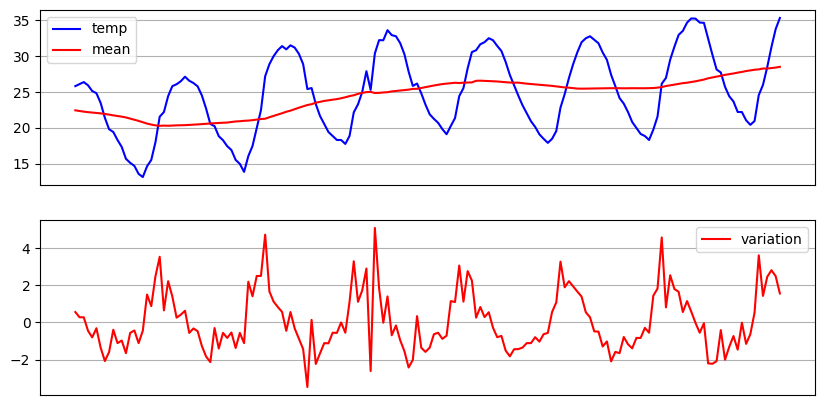

In [773]:
fig, axes = plt.subplots(nrows=2, ncols=1)

# plot temp, mean
df.plot(ax=axes[0],figsize=(10,5),color=['blue','red'],grid=True, legend=True,rot=45,xticks=[])
# 7 jours variation
data.tail(7*24)['variation'].plot(ax=axes[1],figsize=(10,5),color='red',grid=True, legend=True,rot=45,xticks=[])

In [774]:
data.tail(24*7)['temp'].max(),data.tail(24*7)['temp'].min()

(np.float64(35.31), np.float64(13.160000000000023))

In [775]:
def high_low(n):
    # variation 24 heures il y a n jours
    #n = 0
    l = len(data)
    e = n*24
    s = e+24

    high = round(data[l-s:l-e]['temp'].max(),2)
    low = round(data[l-s:l-e]['temp'].min(),2)
    delta = round(high - low,2)
    return high,low,delta

In [776]:
# max, min, delta sur n jours
n = 30
high_n = []
low_n = []
moy_n =  []
delta_n = []
for k in range(n):
    h,l,d = high_low(n-1-k)
    high_n.append(h)
    low_n.append(l)
    moy_n.append((h+l)/2)
    delta_n.append(d)
    print('J',-(n-1-k),h,l,d)


J -29 34.71 23.24 11.47
J -28 32.78 20.78 12.0
J -27 33.61 18.96 14.65
J -26 29.34 17.22 12.12
J -25 30.27 14.35 15.92
J -24 24.5 13.6 10.9
J -23 24.43 13.79 10.64
J -22 25.7 14.82 10.88
J -21 25.56 14.75 10.81
J -20 26.17 14.43 11.74
J -19 29.44 16.66 12.78
J -18 30.27 15.69 14.58
J -17 25.78 14.85 10.93
J -16 30.26 15.56 14.7
J -15 36.65 18.88 17.77
J -14 38.32 19.99 18.33
J -13 29.99 19.19 10.8
J -12 30.0 17.44 12.56
J -11 31.66 15.84 15.82
J -10 35.55 20.55 15.0
J -9 37.77 22.5 15.27
J -8 32.53 19.99 12.54
J -7 28.32 17.63 10.69
J -6 26.38 13.16 13.22
J -5 29.99 13.88 16.11
J -4 31.5 17.77 13.73
J -3 33.61 19.12 14.49
J -2 32.49 17.92 14.57
J -1 32.95 18.32 14.63
J 0 35.31 20.43 14.88


<Axes: >

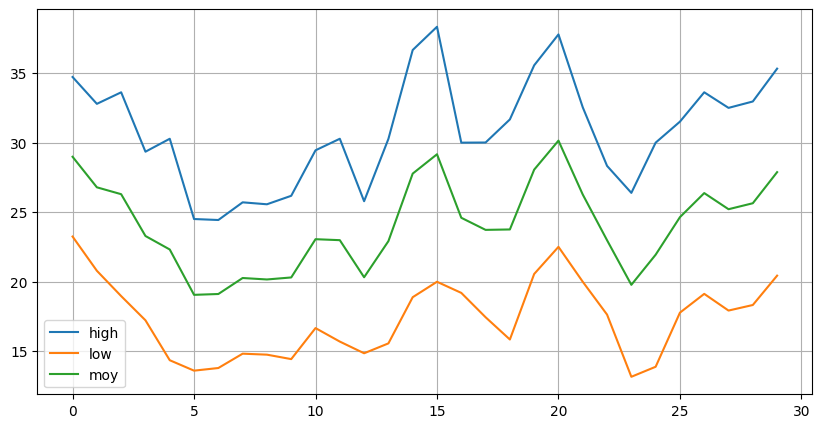

In [777]:
# pandas plot
df1 = pd.DataFrame()
df1['high'] = high_n
df1['low'] = low_n
df1['moy'] = moy_n
df1['delta'] = delta_n
df1[['high','low','moy']].plot(figsize=(10,5),grid=True, legend=True)

In [778]:
_data = list(df1['high'])
_max, _min = local_min_max(_data)
_max


[34.71, 33.61, 30.27, 25.7, 30.27, 38.32, 37.77, 33.61]

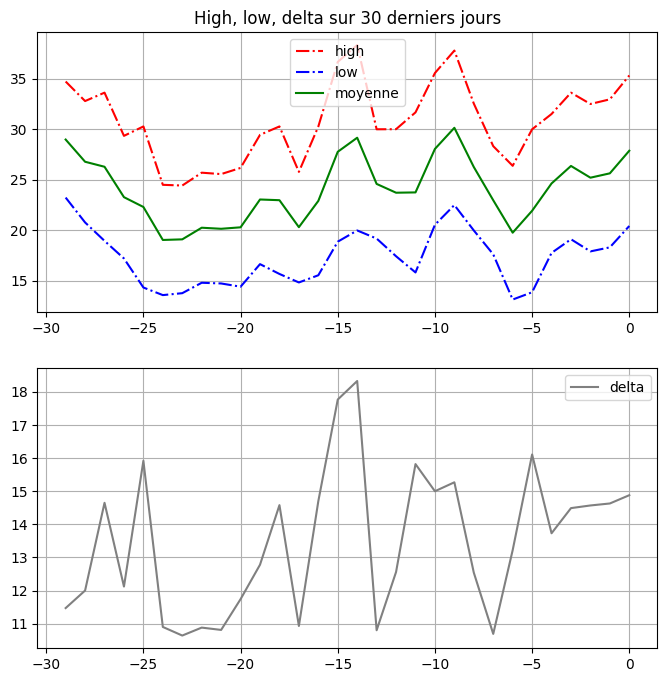

In [779]:
# plot lists
x = range(-29,1,1)
fig, (ax1, ax2) = plt.subplots(2,1)
# the size of A4 paper
fig.set_size_inches(8, 8)
ax1.set_title('High, low, delta sur '+str(n)+' derniers jours')
ax1.plot(x,high_n, '-.',color='red',label='high')
ax1.plot(x,low_n, '-.', color='blue',label = 'low')
ax1.plot(x,moy_n, color='green',label = 'moyenne')
ax1.grid()
ax1.legend()
#moy_n = [(h+l)/2 for h,l in zip(high_n,low_n)]

ax2.plot(x,delta_n,color='grey',label='delta')
ax2.grid()
ax2.legend()

In [780]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20258 entries, 0 to 20257
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   temp       20258 non-null  float64
 1   hours      20258 non-null  float64
 2   dates      20258 non-null  object 
 3   variation  20257 non-null  float64
 4   heures     20258 non-null  object 
 5   jours      20258 non-null  object 
dtypes: float64(3), object(3)
memory usage: 949.7+ KB


In [781]:
data_24 = data.tail(25)[['hours','dates','variation']]
#len(data_24),data_24


In [782]:
# plot X_axis
date_24 = np.array(data.tail(25)['hours'])
#date_24

In [783]:
# inutile ! il faut utiliser le champ data.hours
def mk_date2(data):
    str1, str2 = data_24.head(1)['dates'].values[0] , data_24.tail(1)['dates'].values[0] 
    print(str1,str2)
    return mdates.drange(datetime.strptime(str1, '%d/%m/%y %H:%M:%S'),datetime.strptime(str2, '%d/%m/%y %H:%M:%S'),dt.timedelta(hours=1))
#date_24 = mk_date2(data_24)

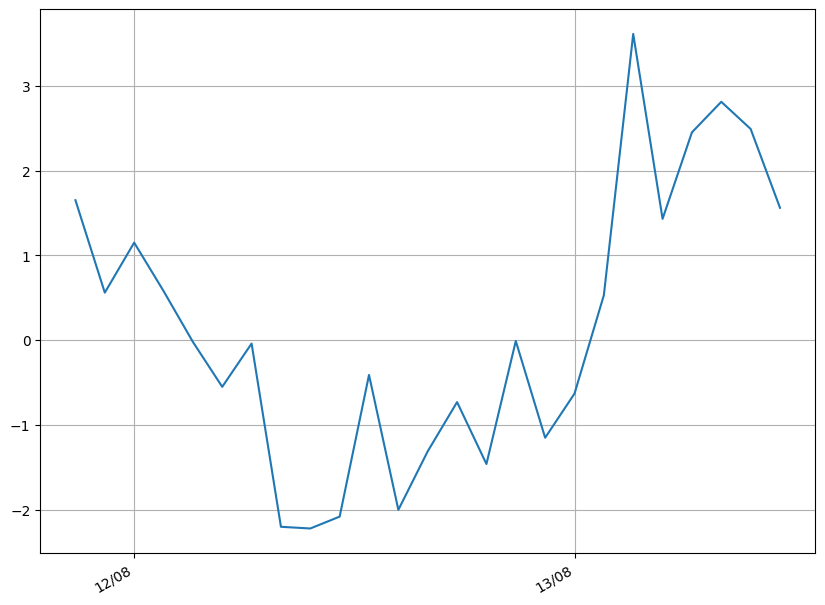

In [784]:
l = len(date_24)
data.tail(l)[['temp','variation']]
var = data.tail(l)[['variation']].values

fig, ax = plt.subplots()
fig.set_size_inches(10, 8)
plt.plot(date_24,var)
format_date()
#plt.grid()

In [785]:
w = int(24*days)
days,data.tail(w)['temp'].max(), data.tail(w)['temp'].min()


(15, np.float64(38.32000000000005), np.float64(13.160000000000023))

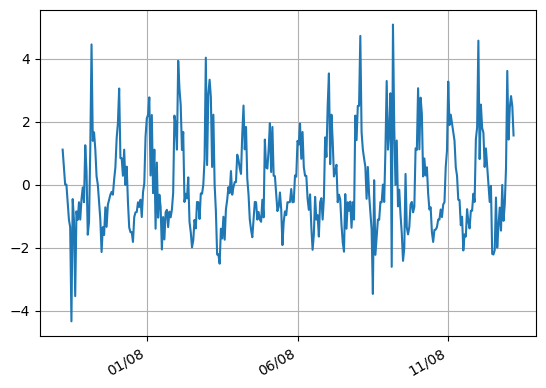

In [786]:
#data['variation'].tail(w).plot()
plt.plot(data['hours'].tail(w),data['variation'].tail(w))
format_date(24)

### date pour les temp max, min

In [787]:
d_max = data.tail(w)['temp'].max()
d_max, data[data['temp']==data.tail(w)['temp'].max()]['dates']

(np.float64(38.32000000000005),
 19899    29/07/26 16:00:00
 19900    29/07/26 17:00:00
 19901    29/07/26 18:00:00
 Name: dates, dtype: object)

In [788]:
d_min = data.tail(w)['temp'].min()
d_min, data[data['temp']==data.tail(w)['temp'].min()]['dates']

(np.float64(13.160000000000023),
 552      14/05/24 13:00:00
 3590     18/09/24 03:00:00
 4712     03/11/24 21:00:00
 9426     19/05/25 07:00:00
 17228    09/04/26 09:00:00
 17444    18/04/26 09:00:00
 20106    07/08/26 07:00:00
 Name: dates, dtype: object)

In [789]:
data.tail(w)['temp'].describe()

count    360.000000
mean      25.099361
std        5.346927
min       13.160000
25%       21.012500
50%       24.835000
75%       28.957500
max       38.320000
Name: temp, dtype: float64

In [790]:
from  datetime import datetime
#matplotlib.dates.date2num(hours)
#then.isoformat(),round(temp[-1],2)
today = datetime.now()




In [791]:
data.tail(1)["dates"].values[0].split(':')[0]


'13/08/26 14'

In [792]:
# current date and time
ts = datetime.timestamp(today)
ts

1786623135.779431